In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import detrend
import scipy.stats as stats
from scipy.stats import bootstrap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
from math import radians, cos
import rasterio
from matplotlib.colors import LinearSegmentedColormap
from rasterio.transform import from_origin
import xskillscore as xs
import shapely.geometry
from shapely.geometry import box
from shapely.ops import unary_union
import matplotlib.patches as mpatches
import pickle
import os

In [2]:
file_path = '/home/madhulika.gurazada/paper2/Data/Nino3.4_OG_SST1.xlsx'

nino34 = pd.read_excel(file_path)

nino34_1900_2024 = nino34[(nino34['Year'] >= 1900) & (nino34['Year'] <= 2024)]

def select_seasons(data):
    # Create DJF (December, January, February) within the function
    djf_data = pd.DataFrame(columns=['Year', 'Dec', 'Jan', 'Feb'])
    djf_data['Year'] = data['Year'] 
    djf_data['Dec'] = data['Dec']
    djf_data['Jan'] = data['Jan'].shift(-1)
    djf_data['Feb'] = data['Feb'].shift(-1)
    
    return djf_data

# Assuming you have already read the data into 'nino34_1900_2022'
djf_data = select_seasons(nino34_1900_2024)

# Define the columns for each season
seasonal_columns = {
    'DJF': ['Dec', 'Jan', 'Feb']
}

# Create a dictionary to hold the DataFrames
seasonal_data = {
    'DJF': djf_data
}

climatology_start_year = 1991
climatology_end_year = 2020

# Calculate seasonal means for each DataFrame
for season, columns in seasonal_columns.items():
    data = seasonal_data[season]
    data[f'{season}_Mean'] = data[columns].mean(axis=1)
    # Filter the data for the climatology years
    climatology_data = data[(data['Year'] >= climatology_start_year) & (data['Year'] <= climatology_end_year)]
    climatology_mean = climatology_data[f'{season}_Mean'].mean()
    climatology_std = climatology_data[f'{season}_Mean'].std()
    # Calculate Nino anomalies
    data[f'Nino_{season}_Anomaly'] = (data[f'{season}_Mean'] - climatology_mean)/climatology_std
    # Classify as El Niño, La Niña, or Neutral
    data[f'Nino_{season}_Classification'] = np.where(data[f'Nino_{season}_Anomaly'] > 0.5, 'El Niño',
                                                     np.where(data[f'Nino_{season}_Anomaly'] < -0.5, 'La Niña', 'Neutral'))
    
el_nino_years = {}
la_nina_years = {}
neutral_years = {}

for season in seasonal_columns.keys():
    data = seasonal_data[season]
    # Extract the years for each classification and filter for years between 1901 and 2024
    el_nino_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'El Niño')]['Year'].tolist()
    la_nina_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'La Niña')]['Year'].tolist()
    neutral_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'Neutral')]['Year'].tolist()

el_nino_years_1 = [year + 1 for year in el_nino_years['DJF']]
la_nina_years_1 = [year + 1 for year in la_nina_years['DJF']]
neutral_years_1 = [year + 1 for year in neutral_years['DJF']]

In [3]:
print(el_nino_years)
print(la_nina_years)
print(neutral_years)

{'DJF': [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]}
{'DJF': [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]}
{'DJF': [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]}


In [4]:
cru_pre = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.pre.dat.nc')
cru_pre.info()  

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
pre_mam_data = cru_pre.sel(time=cru_pre['time.month'].isin(mam_months))
pre_jja_data = cru_pre.sel(time=cru_pre['time.month'].isin(jja_months))
pre_son_data = cru_pre.sel(time=cru_pre['time.month'].isin(son_months))

pre_mam_data['year'] = pre_mam_data['time'].dt.year
pre_mam1_data_year = pre_mam_data['year'] + 1
pre_mam1_data_year = pre_mam1_data_year[pre_mam1_data_year != 2025]
pre_mam1_data = pre_mam_data.sel(time=pre_mam_data['time.year'].isin(pre_mam1_data_year))

pre_jja_data['year'] = pre_jja_data['time'].dt.year
pre_jja1_data_year = pre_jja_data['year'] + 1
pre_jja1_data_year = pre_jja1_data_year[pre_jja1_data_year != 2025]
pre_jja1_data = pre_jja_data.sel(time=pre_jja_data['time.year'].isin(pre_jja1_data_year))

pre_son_data['year'] = pre_son_data['time'].dt.year
pre_son1_data_year = pre_son_data['year'] + 1
pre_son1_data_year = pre_son1_data_year[pre_son1_data_year != 2025]
pre_son1_data = pre_son_data.sel(time=pre_son_data['time.year'].isin(pre_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_pre.sel(time=(cru_pre['time.month'] == 12) & (cru_pre['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_pre.sel(time=(cru_pre['time.month'] == 1) & (cru_pre['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_pre.sel(time=(cru_pre['time.month'] == 2) & (cru_pre['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
pre_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
# pre_mam_mean_yearly = calculate_yearly_mean(pre_mam_data)
pre_jja_mean_yearly = calculate_yearly_mean(pre_jja_data)
pre_son_mean_yearly = calculate_yearly_mean(pre_son_data)
pre_djf_mean_yearly = calculate_yearly_mean(pre_djf_data)
pre_mam1_mean_yearly = calculate_yearly_mean(pre_mam1_data)
pre_jja1_mean_yearly = calculate_yearly_mean(pre_jja1_data)
pre_son1_mean_yearly = calculate_yearly_mean(pre_son1_data)

def plot_precipitation_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    pre_median = dataset['pre'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, pre_median, marker='o', linestyle='-')
    plt.title(f'Precipitation ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    pre_median = dataarray['pre'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_pre_median = detrend(pre_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_pre_median_da = xr.DataArray(
        detrended_pre_median, 
        dims=['year'], 
        coords={'year': pre_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(pre_median['year'], detrended_pre_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Precipitation')
    plt.title(f'Detrended Median Yearly Precipitation ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
# pre_el_nino_composite_mam = pre_mam_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_jja = pre_jja_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_son = pre_son_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_djf = pre_djf_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_mam1 = pre_mam1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_jja1 = pre_jja1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_son1 = pre_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
# pre_mam_el_nino = pre_el_nino_composite_mam.mean(dim='year')['pre']
pre_jja_el_nino = pre_el_nino_composite_jja.mean(dim='year')['pre']
pre_son_el_nino = pre_el_nino_composite_son.mean(dim='year')['pre']
pre_djf_el_nino = pre_el_nino_composite_djf.mean(dim='year')['pre']
pre_mam1_el_nino = pre_el_nino_composite_mam1.mean(dim='year')['pre']
pre_jja1_el_nino = pre_el_nino_composite_jja1.mean(dim='year')['pre']
pre_son1_el_nino = pre_el_nino_composite_son1.mean(dim='year')['pre']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

# pre_la_nina_composite_mam = pre_mam_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_jja = pre_jja_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_son = pre_son_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_djf = pre_djf_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_mam1 = pre_mam1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_jja1 = pre_jja1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_son1 = pre_son1_mean_yearly.sel(year=la_nina_years_1)

# pre_mam_la_nina = pre_la_nina_composite_mam.mean(dim='year')['pre']
pre_jja_la_nina = pre_la_nina_composite_jja.mean(dim='year')['pre']
pre_son_la_nina = pre_la_nina_composite_son.mean(dim='year')['pre']
pre_djf_la_nina = pre_la_nina_composite_djf.mean(dim='year')['pre']
pre_mam1_la_nina = pre_la_nina_composite_mam1.mean(dim='year')['pre']
pre_jja1_la_nina = pre_la_nina_composite_jja1.mean(dim='year')['pre']
pre_son1_la_nina = pre_la_nina_composite_son1.mean(dim='year')['pre']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]
neutral_years_1 = neutral_years_1[:-1]

# pre_neutral_composite_mam = pre_mam_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_jja = pre_jja_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_son = pre_son_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_djf = pre_djf_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_mam1 = pre_mam1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_jja1 = pre_jja1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_son1 = pre_son1_mean_yearly.sel(year=neutral_years_1)

# pre_mam_neutral = pre_neutral_composite_mam.mean(dim='year')['pre']
pre_jja_neutral = pre_neutral_composite_jja.mean(dim='year')['pre']
pre_son_neutral = pre_neutral_composite_son.mean(dim='year')['pre']
pre_djf_neutral = pre_neutral_composite_djf.mean(dim='year')['pre']
pre_mam1_neutral = pre_neutral_composite_mam1.mean(dim='year')['pre']
pre_jja1_neutral = pre_neutral_composite_jja1.mean(dim='year')['pre']
pre_son1_neutral = pre_neutral_composite_son1.mean(dim='year')['pre']

pre_el_nino_differences = [pre_jja_el_nino - pre_jja_neutral, pre_son_el_nino - pre_son_neutral, pre_djf_el_nino - pre_djf_neutral, pre_mam1_el_nino - pre_mam1_neutral, pre_jja1_el_nino - pre_jja1_neutral, pre_son1_el_nino - pre_son1_neutral]
pre_la_nina_differences = [pre_jja_la_nina - pre_jja_neutral, pre_son_la_nina - pre_son_neutral, pre_djf_la_nina - pre_djf_neutral, pre_mam1_la_nina - pre_mam1_neutral, pre_jja1_la_nina - pre_jja1_neutral, pre_son1_la_nina - pre_son1_neutral]

# Get the dimensions of the dataset
lat_size = pre_jja_mean_yearly.dims['lat']
lon_size = pre_jja_mean_yearly.dims['lon']
year_size = pre_jja_mean_yearly.sizes['year']
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': pre_jja_mean_yearly['year'], 'lat': pre_jja_mean_yearly['lat'], 
                                           'lon': pre_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = pre_jja_mean_yearly['pre'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['pre'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

datasets = {'pre_jja_mean_yearly': pre_jja_mean_yearly,
            'pre_son_mean_yearly': pre_son_mean_yearly,
            'pre_djf_mean_yearly': pre_djf_mean_yearly,
            'pre_mam1_mean_yearly': pre_mam1_mean_yearly,
            'pre_jja1_mean_yearly': pre_jja1_mean_yearly,
            'pre_son1_mean_yearly': pre_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-20, vmax=20)

    # Add colorbar
    plt.colorbar(label='Detrended Precipitation')

    # Add title and labels
    plt.title(f'Detrended Precipitation for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()
    
# List of the datasets
pre_datasets = [detrended_datasets_xr['pre_jja_mean_yearly'], detrended_datasets_xr['pre_son_mean_yearly'], detrended_datasets_xr['pre_djf_mean_yearly'], detrended_datasets_xr['pre_mam1_mean_yearly'], detrended_datasets_xr['pre_jja1_mean_yearly'], detrended_datasets_xr['pre_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
pre_datasets_climatology = []

# Loop through each dataset and select the climatology period
for pre_dataset in pre_datasets:
    pre_dataset_climatology = pre_dataset.sel(year=climatology_period)
    pre_datasets_climatology.append(pre_dataset_climatology)
    
# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for pre_dataset_climatology in pre_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = pre_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = pre_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)

standardized_anomalies = []

for pre_dataset, mean, std_dev in zip(pre_datasets, means, std_devs):
    standardized_anomaly = (pre_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_pre_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

if len(la_nina_years_djf) > 0:
    la_nina_years_djf.pop()

for i in range(6):
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_pre_anom_el = el_nino_std_anom
std_pre_anom_la = la_nina_std_anom
std_pre_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 pre(time, lat, lon) ;
		pre:long_name = precipitation ;
		pre:units = mm/month ;
		pre:correlation_decay_distance = 450.0 ;
	float64 stn(time, lat, lon) ;
		stn:description = number of stations contributing to each datum ;
	float32 mae(time, lat, lon) ;
		mae:description = mean of absolute diffs between interpolant anomalies and interpolated anomaly, where available ;
	float32 maea(time, lat, lon) ;
		maea:description = MAE anomaly, relative to long-term mean ;

// global attributes:
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Precipitation ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:pre.2503051121.dtb ;

In [5]:
cru_tmx = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.tmx.dat.nc')
cru_tmx.info()

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
tmx_mam_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(mam_months))
tmx_jja_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(jja_months))
tmx_son_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(son_months))

tmx_mam_data['year'] = tmx_mam_data['time'].dt.year
tmx_mam1_data_year = tmx_mam_data['year'] + 1
tmx_mam1_data_year = tmx_mam1_data_year[tmx_mam1_data_year != 2025]
tmx_mam1_data = tmx_mam_data.sel(time=tmx_mam_data['time.year'].isin(tmx_mam1_data_year))

tmx_jja_data['year'] = tmx_jja_data['time'].dt.year
tmx_jja1_data_year = tmx_jja_data['year'] + 1
tmx_jja1_data_year = tmx_jja1_data_year[tmx_jja1_data_year != 2025]
tmx_jja1_data = tmx_jja_data.sel(time=tmx_jja_data['time.year'].isin(tmx_jja1_data_year))

tmx_son_data['year'] = tmx_son_data['time'].dt.year
tmx_son1_data_year = tmx_son_data['year'] + 1
tmx_son1_data_year = tmx_son1_data_year[tmx_son1_data_year != 2025]
tmx_son1_data = tmx_son_data.sel(time=tmx_son_data['time.year'].isin(tmx_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_tmx.sel(time=(cru_tmx['time.month'] == 12) & (cru_tmx['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_tmx.sel(time=(cru_tmx['time.month'] == 1) & (cru_tmx['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_tmx.sel(time=(cru_tmx['time.month'] == 2) & (cru_tmx['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
tmx_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
tmx_jja_mean_yearly = calculate_yearly_mean(tmx_jja_data)
tmx_son_mean_yearly = calculate_yearly_mean(tmx_son_data)
tmx_djf_mean_yearly = calculate_yearly_mean(tmx_djf_data)
tmx_mam1_mean_yearly = calculate_yearly_mean(tmx_mam1_data)
tmx_jja1_mean_yearly = calculate_yearly_mean(tmx_jja1_data)
tmx_son1_mean_yearly = calculate_yearly_mean(tmx_son1_data)

def plot_temperature_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    tmx_median = dataset['tmx'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, tmx_median, marker='o', linestyle='-')
    plt.title(f'Temperature ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Tmax (degC)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    tmx_median = dataarray['tmx'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_tmx_median = detrend(tmx_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_tmx_median_da = xr.DataArray(
        detrended_tmx_median, 
        dims=['year'], 
        coords={'year': tmx_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(tmx_median['year'], detrended_tmx_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Max Temperature')
    plt.title(f'Detrended Median Yearly Max Temperature ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
el_nino_composite_jja = tmx_jja_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_son = tmx_son_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_djf = tmx_djf_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_mam1 = tmx_mam1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_jja1 = tmx_jja1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_son1 = tmx_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
tmx_jja_el_nino = el_nino_composite_jja.mean(dim='year')['tmx']
tmx_son_el_nino = el_nino_composite_son.mean(dim='year')['tmx']
tmx_djf_el_nino = el_nino_composite_djf.mean(dim='year')['tmx']
tmx_mam1_el_nino = el_nino_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_el_nino = el_nino_composite_jja1.mean(dim='year')['tmx']
tmx_son1_el_nino = el_nino_composite_son1.mean(dim='year')['tmx']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

la_nina_composite_jja = tmx_jja_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_son = tmx_son_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_djf = tmx_djf_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_mam1 = tmx_mam1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_jja1 = tmx_jja1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_son1 = tmx_son1_mean_yearly.sel(year=la_nina_years_1)

tmx_jja_la_nina = la_nina_composite_jja.mean(dim='year')['tmx']
tmx_son_la_nina = la_nina_composite_son.mean(dim='year')['tmx']
tmx_djf_la_nina = la_nina_composite_djf.mean(dim='year')['tmx']
tmx_mam1_la_nina = la_nina_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_la_nina = la_nina_composite_jja1.mean(dim='year')['tmx']
tmx_son1_la_nina = la_nina_composite_son1.mean(dim='year')['tmx']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]

neutral_composite_jja = tmx_jja_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_son = tmx_son_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_djf = tmx_djf_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_mam1 = tmx_mam1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_jja1 = tmx_jja1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_son1 = tmx_son1_mean_yearly.sel(year=neutral_years_1)

tmx_jja_neutral = neutral_composite_jja.mean(dim='year')['tmx']
tmx_son_neutral = neutral_composite_son.mean(dim='year')['tmx']
tmx_djf_neutral = neutral_composite_djf.mean(dim='year')['tmx']
tmx_mam1_neutral = neutral_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_neutral = neutral_composite_jja1.mean(dim='year')['tmx']
tmx_son1_neutral = neutral_composite_son1.mean(dim='year')['tmx']

tmx_el_nino_differences = [tmx_jja_el_nino - tmx_jja_neutral, tmx_son_el_nino - tmx_son_neutral, tmx_djf_el_nino - tmx_djf_neutral, tmx_mam1_el_nino - tmx_mam1_neutral, tmx_jja1_el_nino - tmx_jja1_neutral, tmx_son1_el_nino - tmx_son1_neutral]
tmx_la_nina_differences = [tmx_jja_la_nina - tmx_jja_neutral, tmx_son_la_nina - tmx_son_neutral, tmx_djf_la_nina - tmx_djf_neutral, tmx_mam1_la_nina - tmx_mam1_neutral, tmx_jja1_la_nina - tmx_jja1_neutral, tmx_son1_la_nina - tmx_son1_neutral]

# Get the dimensions of the dataset
lat_size = tmx_jja_mean_yearly.dims['lat']
lon_size = tmx_jja_mean_yearly.dims['lon']
year_size = tmx_jja_mean_yearly.sizes['year']
# Create an array to store the detrended data
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': tmx_jja_mean_yearly['year'], 'lat': tmx_jja_mean_yearly['lat'], 
                                           'lon': tmx_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = tmx_jja_mean_yearly['tmx'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['tmx'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

# Example datasets (replace with your actual datasets)
datasets = {'tmx_jja_mean_yearly': tmx_jja_mean_yearly,
            'tmx_son_mean_yearly': tmx_son_mean_yearly,
            'tmx_djf_mean_yearly': tmx_djf_mean_yearly,
            'tmx_mam1_mean_yearly': tmx_mam1_mean_yearly,
            'tmx_jja1_mean_yearly': tmx_jja1_mean_yearly,
            'tmx_son1_mean_yearly': tmx_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)

    # Add colorbar
    plt.colorbar(label='Detrended Max Temperature')

    # Add title and labels
    plt.title(f'Detrended Max Temperature for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()

# List of the datasets
tmx_datasets = [detrended_datasets_xr['tmx_jja_mean_yearly'], detrended_datasets_xr['tmx_son_mean_yearly'], detrended_datasets_xr['tmx_djf_mean_yearly'], detrended_datasets_xr['tmx_mam1_mean_yearly'], detrended_datasets_xr['tmx_jja1_mean_yearly'], detrended_datasets_xr['tmx_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
tmx_datasets_climatology = []

# Loop through each dataset and select the climatology period
for tmx_dataset in tmx_datasets:
    tmx_dataset_climatology = tmx_dataset.sel(year=climatology_period)
    tmx_datasets_climatology.append(tmx_dataset_climatology)

# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for tmx_dataset_climatology in tmx_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = tmx_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = tmx_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)
    
standardized_anomalies = []

for tmx_dataset, mean, std_dev in zip(tmx_datasets, means, std_devs):
    standardized_anomaly = (tmx_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_tmx_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

for i in range(6):  # 0 to 2, as range(3) generates 0, 1, 2
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_tmx_anom_el = el_nino_std_anom
std_tmx_anom_la = la_nina_std_anom
std_tmx_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 tmx(time, lat, lon) ;
		tmx:long_name = near-surface temperature maximum ;
		tmx:units = degrees Celsius ;
		tmx:correlation_decay_distance = 1200.0 ;
	float64 stn(time, lat, lon) ;

// global attributes:
	:description = number of DTR stations contributing to each datum, TMP counts may be higher or lower ;
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Maximum Temperature ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:TMX derived from gridded TMP & DTR absolutes, DTR in turn derived from tmn.2503051121.dtb, tmx.2503051121.dtb ;
	:history = Wed  5 Mar 20:47:26 GMT 2025 : User f098 : Program makegridsauto.for ca

In [6]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season].sum(dim='year')
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season].sum(dim='year')

In [7]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season]
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season]

In [8]:
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc')
cropland_0p5.where(cropland_0p5['Band1'] > 0)

<xarray.Dataset>
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    Band1    (lat, lon) float32 nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    CDI:                 Climate Data Interface version 1.9.8 (https://mpimet...
    Conventions:         CF-1.5
    history:             Wed Mar 06 15:48:49 2024: cdo remapcon,cru_ts4.06.19...
    GDAL_AREA_OR_POINT:  Area
    GDAL:                GDAL 2.3.1, released 2018/06/22
    CDO:                 Climate Data Operators version 1.9.8 (https://mpimet...

In [9]:
maize = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_maize.nc")
rice = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_rice.nc")
soybean = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_soybean.nc")
wheat = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_wheat.nc")
total_cropland = cropland_0p5

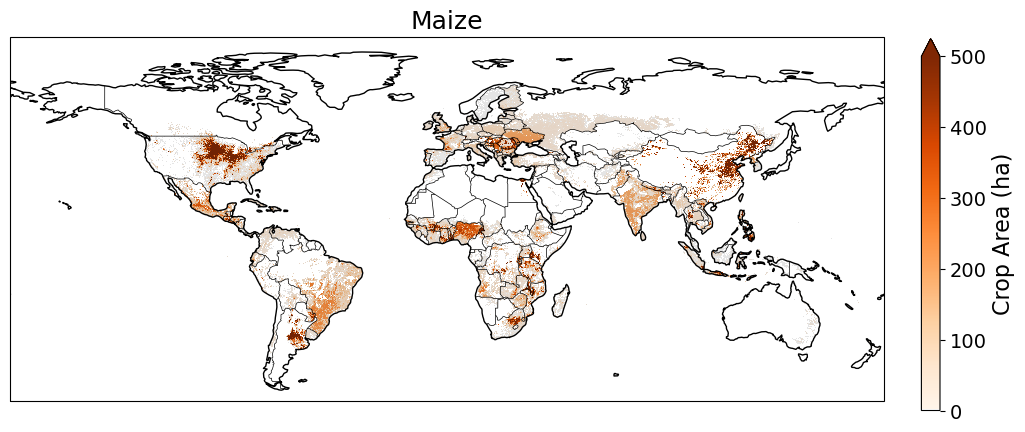

In [10]:
masked_maize = maize['croparea'].where(maize['croparea'] > 0)

# Define latitude and longitude bounds (example: lat: -40 to 40, lon: -180 to 180)
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the maize dataset based on the defined bounds
subset_maize = masked_maize.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.Oranges
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_maize.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_maize['lon'], subset_maize['lat'], subset_maize,
    cmap=cmap, shading='auto', vmin=0, vmax=500
)
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_maize['lon'], subset_maize['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

ax.add_feature(
    cfeature.BORDERS.with_scale('110m'),
    edgecolor='black',
    linewidth=0.5
)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="Crop Area (ha)", fraction=0.02, pad=0.04, extend='max')
cbar.set_ticks([0, 100, 200, 300, 400, 500])  # Set specific ticks if needed
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel("Crop Area (ha)", fontsize=16)

# Labels and title
ax.set_title("Maize", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

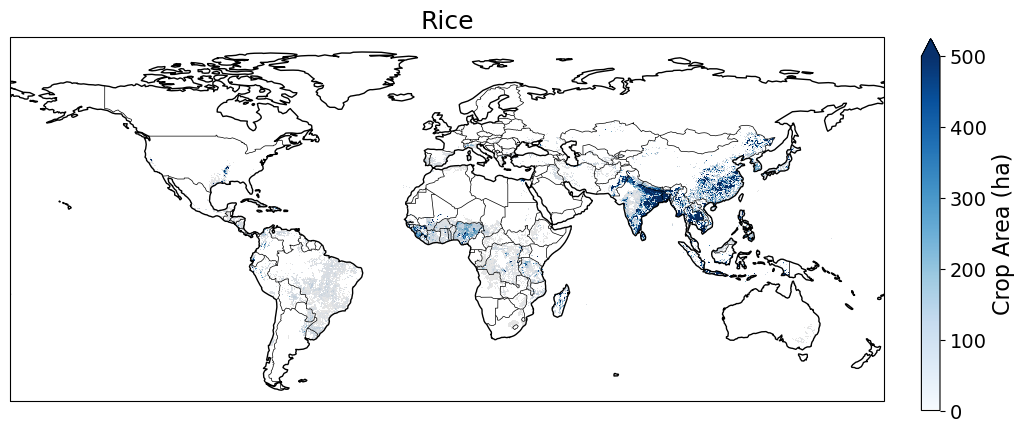

In [11]:
masked_rice = rice['croparea'].where(rice['croparea'] > 0)

# Define latitude and longitude bounds (example: lat: -40 to 40, lon: -180 to 180)
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the rice dataset based on the defined bounds
subset_rice = masked_rice.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.Blues
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_rice.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_rice['lon'], subset_rice['lat'], subset_rice,
    cmap=cmap, shading='auto', vmin=0, vmax=500
)
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_rice['lon'], subset_rice['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

ax.add_feature(
    cfeature.BORDERS.with_scale('110m'),
    edgecolor='black',
    linewidth=0.5
)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="Crop Area (ha)", fraction=0.02, pad=0.04, extend='max')
cbar.set_ticks([0, 100, 200, 300, 400, 500])  # Set specific ticks if needed
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel("Crop Area (ha)", fontsize=16)

# Set the title and labels
ax.set_title("Rice", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

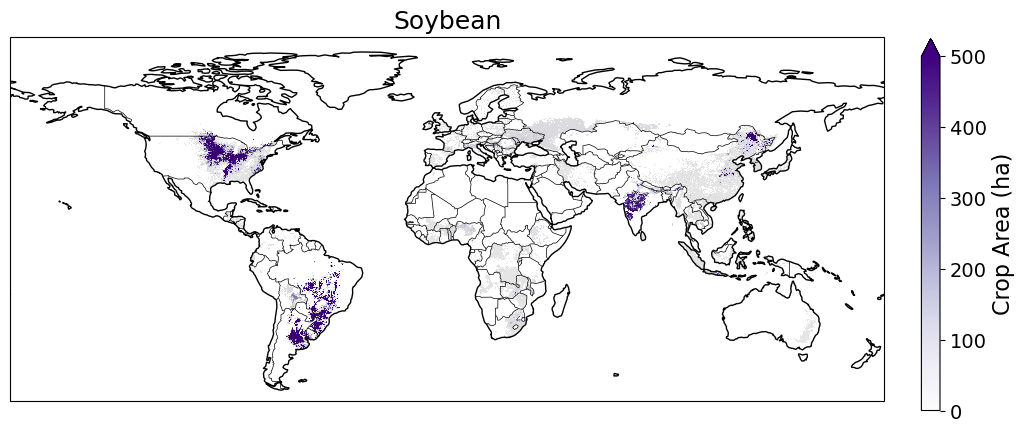

In [12]:
# Mask the crop area data to exclude negative values (oceans)
masked_soybean = soybean['croparea'].where(soybean['croparea'] > 0)

# Define latitude and longitude bounds
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the soybean dataset based on the defined bounds
subset_soybean = masked_soybean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.Purples
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_soybean.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_soybean['lon'], subset_soybean['lat'], subset_soybean,
    cmap=cmap, shading='auto', vmin=0, vmax=500  # Use 'Blues' colormap
)
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_soybean['lon'], subset_soybean['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

ax.add_feature(
    cfeature.BORDERS.with_scale('110m'),
    edgecolor='black',
    linewidth=0.5
)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="Crop Area (ha)", fraction=0.02, pad=0.04, extend='max')
cbar.set_ticks([0, 100, 200, 300, 400, 500])  # Set specific ticks if needed
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel("Crop Area (ha)", fontsize=16)

# Set the title and labels
ax.set_title("Soybean", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

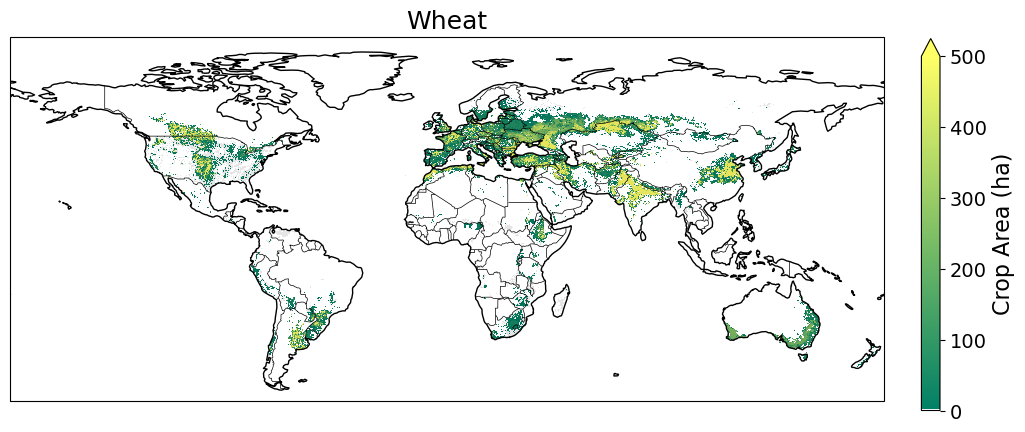

In [13]:
# Mask the crop area data to exclude negative values (oceans)
masked_wheat = wheat['croparea'].where(wheat['croparea'] > 0)

# Define latitude and longitude bounds
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the wheat dataset based on the defined bounds
subset_wheat = masked_wheat.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.summer
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_wheat.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_wheat['lon'], subset_wheat['lat'], subset_wheat,
    cmap=cmap, shading='auto', vmin=0, vmax=500  # Use 'Purples' colormap
)
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_wheat['lon'], subset_wheat['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

ax.add_feature(
    cfeature.BORDERS.with_scale('110m'),
    edgecolor='black',
    linewidth=0.5
)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="Crop Area (ha)", fraction=0.02, pad=0.04, extend='max')
cbar.set_ticks([0, 100, 200, 300, 400, 500])  # Set specific ticks if needed
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel("Crop Area (ha)", fontsize=16)

# Set the title and labels
ax.set_title("Wheat", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

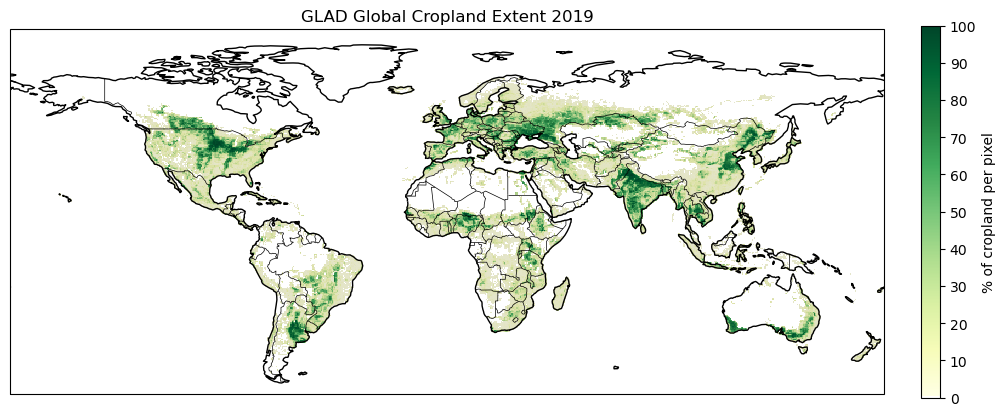

In [14]:
# Mask the crop area data to exclude negative values (oceans)
masked_total_cropland = total_cropland['Band1'].where(total_cropland['Band1'] > 0)

# Define latitude and longitude bounds
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the wheat dataset based on the defined bounds
subset_total_cropland = masked_total_cropland.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.YlGn
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_total_cropland.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_total_cropland['lon'], subset_total_cropland['lat'], subset_total_cropland,
    cmap=cmap, shading='auto', vmin=0, vmax=100) 
    
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_total_cropland['lon'], subset_total_cropland['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

ax.add_feature(
    cfeature.BORDERS.with_scale('110m'),
    edgecolor='black',
    linewidth=0.5
)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="% of cropland per pixel", fraction=0.02, pad=0.04)
cbar.set_ticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])  # Set specific ticks if needed

# Set the title and labels
ax.set_title("GLAD Global Cropland Extent 2019")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

In [15]:
maize_crop_area = masked_maize.where(masked_maize > 0).sum().item()
rice_crop_area = masked_rice.where(masked_rice > 0).sum().item()
soybean_crop_area = masked_soybean.where(masked_soybean > 0).sum().item()
wheat_crop_area = masked_wheat.where(masked_wheat > 0).sum().item()

# Print the results
print(f"Total Maize Area (ha): {maize_crop_area}")
print(f"Total Rice Area (ha): {rice_crop_area}")
print(f"Total Soybean Area (ha): {soybean_crop_area}")
print(f"Total Wheat Area (ha): {wheat_crop_area}")

Total Maize Area (ha): 191679344.0
Total Rice Area (ha): 129679208.0
Total Soybean Area (ha): 124230280.0
Total Wheat Area (ha): 206507248.0


In [16]:
def ha_to_sq_km(hectares):
    return hectares * 0.01

# Convert crop areas
maize_crop_area_sq_km = ha_to_sq_km(maize_crop_area)
rice_crop_area_sq_km = ha_to_sq_km(rice_crop_area)
soybean_crop_area_sq_km = ha_to_sq_km(soybean_crop_area)
wheat_crop_area_sq_km = ha_to_sq_km(wheat_crop_area)

# Print the results
print(f"Total Maize Area (km²): {maize_crop_area_sq_km}")
print(f"Total Rice Area (km²): {rice_crop_area_sq_km}")
print(f"Total Soybean Area (km²): {soybean_crop_area_sq_km}")
print(f"Total Wheat Area (km²): {wheat_crop_area_sq_km}")

Total Maize Area (km²): 1916793.44
Total Rice Area (km²): 1296792.08
Total Soybean Area (km²): 1242302.8
Total Wheat Area (km²): 2065072.48


In [17]:
maize_km2 = masked_maize * 0.01
rice_km2 = masked_rice * 0.01
soybean_km2 = masked_soybean * 0.01
wheat_km2 = masked_wheat * 0.01

In [18]:
maize_ha = maize_km2 * 100
rice_ha = rice_km2 * 100
soybean_ha = soybean_km2 * 100
wheat_ha = wheat_km2 * 100

In [19]:
# Fractional cropland (0–100%) → convert to 0–1
cropland_fraction = total_cropland['Band1'].where(total_cropland['Band1'] > 0) / 100.0

# Convert degrees to radians for latitude
lat_rad = np.deg2rad(cropland_fraction['lat'])

# Earth's radius (km)
R = 6371

# Grid cell area (lat-dependent, same for all longitudes)
dlat = dlon = np.deg2rad(0.5)  # resolution in radians
grid_area_1d = (R**2) * dlat * dlon * np.cos(lat_rad)

# Expand to 2D to match shape of cropland_fraction
grid_area_2d = xr.DataArray(
    np.repeat(grid_area_1d.values[:, np.newaxis], len(cropland_fraction['lon']), axis=1),
    coords=[cropland_fraction['lat'], cropland_fraction['lon']],
    dims=['lat', 'lon']
)

# make grid area in hectares instead of km²
grid_area_2d_ha = grid_area_2d * 100

# Compute cropland area per cell and sum
total_cropland_km2 = (cropland_fraction * grid_area_2d).sum(skipna=True).item()

print(f"Total Cropland Area (km²): {total_cropland_km2:.2f}")

total_cropland_ha = (cropland_fraction * grid_area_2d_ha).sum(skipna=True).item()

print(f"Total Cropland Area: {total_cropland_ha:,.0f} ha")

Total Cropland Area (km²): 17102392.00
Total Cropland Area: 1,710,239,104 ha


In [20]:
total_cropland_km2 = cropland_fraction * grid_area_2d
total_cropland_ha = cropland_fraction * grid_area_2d_ha

In [21]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_conditions = {condition: {} for condition in datasets.keys()}
hot_wet_conditions = {condition: {} for condition in datasets.keys()}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Calculate hot-dry and hot-wet masks
        hot_dry_mask = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_mask = (data["tmx"][i] > 1) & (data["pre"][i] > 1)  # Hot and wet
        
        # Drop non-relevant grid cells
        hot_dry_conditions[condition][season] = hot_dry_mask
        hot_wet_conditions[condition][season] = hot_wet_mask

In [22]:
total_maize_area_ha = maize_ha.sum(skipna=True).item()
print(f"Total maize area: {total_maize_area_ha:.2f} ha")

Total maize area: 191679344.00 ha


In [23]:
hot_dry_conditions['el']['jja'][0]

<xarray.DataArray (lat: 360, lon: 720)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    year     int64 1902
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [24]:
# Extract relevant data
hot_dry_mask = hot_dry_conditions['el']['jja'][1]  # Boolean mask (coarse resolution)
coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes

fine_lat = maize_ha.lat.values  # Fine grid latitudes
fine_lon = maize_ha.lon.values  # Fine grid longitudes

total_crop_area = 0  # Variable to store total crop area

# Define half the resolution step to create bounding boxes
coarse_res = 0.5  # Coarse grid cell size
half_res = coarse_res / 2  # Half-cell width

# Loop through each coarse grid cell
for i in range(len(coarse_lat)):
    for j in range(len(coarse_lon)):
        if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
            # Define the bounding box for this coarse grid cell
            lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
            lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
            
            # Select the corresponding high-resolution grid cells from maize_km2
            fine_grid_cells = maize_ha.sel(
                lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
            )
            
            # Sum up the maize area in these fine-grid cells
            total_crop_area += np.nansum(fine_grid_cells)

# Print final result
print(f"Total maize crop area (ha) in hot-dry regions during EL Niño JJA: {total_crop_area:.2f} ha")

Total maize crop area (ha) in hot-dry regions during EL Niño JJA: 5160029.43 ha


In [25]:
# Dictionary of crop datasets
crop_datasets = {
    "total": total_cropland_ha,
    "maize": maize_ha,
    "rice": rice_ha,
    "soybean": soybean_ha,
    "wheat": wheat_ha
}

In [26]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "total"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_dry_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_dry_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_dry_conditions[condition][season])):
#             hot_dry_mask = hot_dry_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [27]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "total"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_wet_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_wet_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_wet_conditions[condition][season])):
#             hot_wet_mask = hot_wet_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_wet_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_wet_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_wet_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [28]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "maize"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_dry_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_dry_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_dry_conditions[condition][season])):
#             hot_dry_mask = hot_dry_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [29]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "maize"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_wet_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_wet_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_wet_conditions[condition][season])):
#             hot_wet_mask = hot_wet_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_wet_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_wet_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_wet_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [30]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "rice"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_dry_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_dry_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_dry_conditions[condition][season])):
#             hot_dry_mask = hot_dry_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [31]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "rice"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_wet_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_wet_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_wet_conditions[condition][season])):
#             hot_wet_mask = hot_wet_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_wet_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_wet_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_wet_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [32]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "soybean"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_dry_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_dry_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_dry_conditions[condition][season])):
#             hot_dry_mask = hot_dry_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [33]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "soybean"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_wet_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_wet_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_wet_conditions[condition][season])):
#             hot_wet_mask = hot_wet_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_wet_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_wet_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_wet_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [34]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "wheat"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_dry_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_dry_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_dry_conditions[condition][season])):
#             hot_dry_mask = hot_dry_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [35]:
# # Define resolution parameters
# coarse_res = 0.5  # Coarse grid cell size
# half_res = coarse_res / 2  # Half-cell width

# # Dictionary to store total crop areas for rice
# crop_areas = {}
# crop_name = "wheat"
# crop_data = crop_datasets[crop_name]
# crop_areas[crop_name] = {}

# # Loop through ENSO conditions
# for condition in hot_wet_conditions.keys():
#     crop_areas[crop_name][condition] = {}
    
#     # Loop through each season
#     for season in hot_wet_conditions[condition].keys():
#         crop_areas[crop_name][condition][season] = []
        
#         # Loop through each year index
#         for year_idx in range(len(hot_wet_conditions[condition][season])):
#             hot_wet_mask = hot_wet_conditions[condition][season][year_idx]  # Boolean mask
#             coarse_lat = hot_wet_mask.lat.values  # Coarse grid latitudes
#             coarse_lon = hot_wet_mask.lon.values  # Coarse grid longitudes
            
#             total_crop_area = 0  # Variable to store total crop area
            
#             # Loop through each coarse grid cell
#             for i in range(len(coarse_lat)):
#                 for j in range(len(coarse_lon)):
#                     if hot_wet_mask.values[i, j]:  # If hot-dry condition is True
#                         # Define bounding box for this coarse grid cell
#                         lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
#                         lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
                        
#                         # Select the corresponding high-resolution grid cells from crop_data
#                         fine_grid_cells = crop_data.sel(
#                             lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
#                         )
                        
#                         # Sum up the crop area in these fine-grid cells
#                         total_crop_area += np.nansum(fine_grid_cells)
            
#             # Store total crop area for this year
#             crop_areas[crop_name][condition][season].append(total_crop_area)
        
#         # Compute mean crop area across years for this condition and season
#         crop_areas[crop_name][condition][season] = np.mean(crop_areas[crop_name][condition][season])

# # Print final results
# print(f"Crop: {crop_name}")
# for condition, seasons in crop_areas[crop_name].items():
#     for season, avg_area in seasons.items():
#         print(f"{condition} - {season}: {avg_area:.2f} ha")

In [36]:
# # Ensure crop_data coordinates are sorted for slicing
# crop_data = crop_data.sortby(['lat', 'lon'])

# # Check lat/lon ranges
# print(crop_data.lat.min().item(), crop_data.lat.max().item())
# print(crop_data.lon.min().item(), crop_data.lon.max().item())
# print(hot_dry_conditions['el']['jja'][0].lat.min().item(), hot_dry_conditions['el']['jja'][0].lat.max().item())
# print(hot_dry_conditions['el']['jja'][0].lon.min().item(), hot_dry_conditions['el']['jja'][0].lon.max().item())

In [37]:
crop_datasets["maize2"] = crop_datasets["maize"]
crop_datasets["rice2"] = crop_datasets["rice"]
crop_datasets["soybeans"] = crop_datasets["soybean"]
crop_datasets["wheatwinter"] = crop_datasets["wheat"]

In [38]:
# Load crop calendar datasets
datasets = {
    "maize": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.crop.calendar.fill.nc'),
    "maize2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.2.crop.calendar.fill.nc'),
    "rice": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.crop.calendar.fill.nc'),
    "rice2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.2.crop.calendar.fill.nc'),
    "soybeans": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Soybeans.crop.calendar.fill.nc'),
    "wheat": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.crop.calendar.fill.nc'),
    "wheatwinter": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.Winter.crop.calendar.fill.nc'),
}

In [39]:
# coarse_crop_areas = {}  # Output: {crop_name: coarse-resolution area}

# # Coarse-resolution target (360x720) from calendar
# coarse_lat = datasets["maize"]["plant"].latitude
# coarse_lon = datasets["maize"]["plant"].longitude

# # Step size for bounding box (0.5° grid)
# half_deg = 0.25

# # Crop list to loop over
# crop_list = ["maize", "maize2", "rice", "rice2", "soybeans", "wheat", "wheatwinter"]

# for crop in crop_list:
#     print(f"Processing: {crop}")
    
#     fine_area = crop_datasets[crop]
    
#     # Init empty 360x720 grid
#     coarse_area = xr.DataArray(
#         np.zeros((len(coarse_lat), len(coarse_lon))),
#         coords={"latitude": coarse_lat, "longitude": coarse_lon},
#         dims=["latitude", "longitude"]
#     )

#     # Loop through each coarse grid cell
#     for i, lat_c in enumerate(coarse_lat.values):
#         for j, lon_c in enumerate(coarse_lon.values):
#             lat_min = lat_c - half_deg
#             lat_max = lat_c + half_deg
#             lon_min = lon_c - half_deg
#             lon_max = lon_c + half_deg

#             fine_subset = fine_area.sel(
#                 lat=slice(lat_min, lat_max),
#                 lon=slice(lon_min, lon_max)
#             )

#             if fine_subset.size > 0:
#                 coarse_area[i, j] = fine_subset.sum(skipna=True)

#     # Store result
#     coarse_crop_areas[crop] = coarse_area

#     print(f"  Total area: {coarse_area.sum().item():,.2f}")

In [40]:
# # Combine into one Dataset
# coarse_crop_areas = xr.Dataset({crop: coarse_crop_areas[crop] for crop in coarse_crop_areas})

# # Save to NetCDF
# coarse_crop_areas.to_netcdf("/home/madhulika.gurazada/paper2/Data/Crop_areas_0.5deg/coarse_crop_areas_0.5deg.nc")

In [41]:
# Load entire dataset
coarse_crop_areas = xr.load_dataset("/home/madhulika.gurazada/paper2/Data/Crop_areas_0.5deg/coarse_crop_areas_0.5deg.nc")

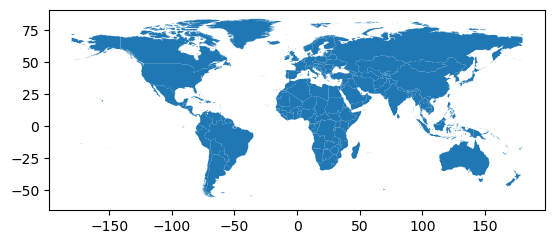

In [42]:
# Specify the path to your shapefile
shapefile_path = '/home/madhulika.gurazada/paper2/Data/Country_polygons/world-administrative-boundaries.shp'

# Load the shapefile using geopandas
cont = gpd.read_file(shapefile_path)

# Plot the shapefile
cont.plot()
plt.show()

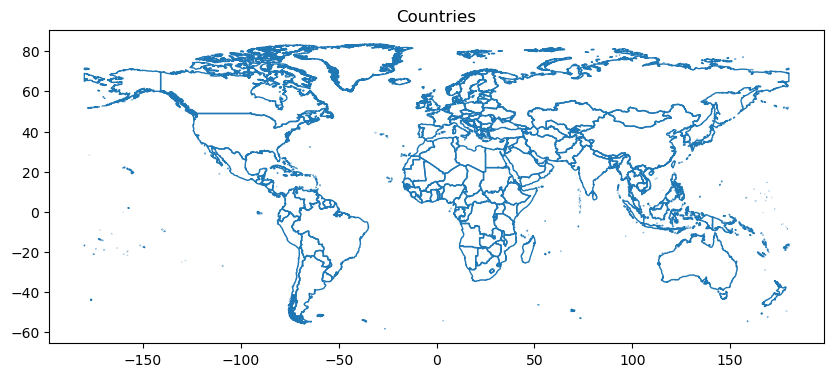

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the shapefile with acronyms
cont.boundary.plot(ax=ax, linewidth=1)  # Plot the boundaries without filling
# cont.apply(lambda x: ax.text(x.geometry.centroid.x, x.geometry.centroid.y, x['name'], fontsize=8, ha='center'), axis=1)

# Add labels and title
plt.title('Countries')

# Show the plot
plt.show()

In [44]:
# # Set resolution
# coarse_res = 0.5
# half_res = coarse_res / 2
# crop_name = "total"
# crop_data = crop_datasets[crop_name]

# # Output dictionaries
# cont_crop_areas = {}
# el_crop_areas = {}
# la_crop_areas = {}
# ne_crop_areas = {}

# # ENSO lookup
# enso_dict = {"el": el_crop_areas, "la": la_crop_areas, "ne": ne_crop_areas}

# for idx, region in cont.iterrows():
#     region_name = region['name']
#     print(f"Processing region: {region_name}")
#     region_geom = region.geometry

#     cont_crop_areas[region_name] = {cond: {} for cond in hot_dry_conditions.keys()}

#     # Initialize ENSO-specific containers
#     for enso_dict_key in enso_dict:
#         if region_name not in enso_dict[enso_dict_key]:
#             enso_dict[enso_dict_key][region_name] = {}

#     for condition in hot_dry_conditions.keys():
#         for season in hot_dry_conditions[condition].keys():
#             yearly_areas = []

#             for year_idx in range(len(hot_dry_conditions[condition][season])):
#                 mask = hot_dry_conditions[condition][season][year_idx]
#                 lat_vals = mask.lat.values
#                 lon_vals = mask.lon.values
#                 total_crop_area = 0

#                 for i, lat in enumerate(lat_vals):
#                     for j, lon in enumerate(lon_vals):
#                         if mask.values[i, j]:
#                             cell_geom = box(lon - half_res, lat - half_res, lon + half_res, lat + half_res)

#                             if region_geom.intersects(cell_geom):
#                                 lat_min, lat_max = lat - half_res, lat + half_res
#                                 lon_min, lon_max = lon - half_res, lon + half_res
#                                 fine_area = crop_data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
#                                 total_crop_area += np.nansum(fine_area)

#                 yearly_areas.append(total_crop_area)

#             # Store all yearly values
#             enso_dict[condition][region_name][season] = yearly_areas

#             # Also store mean
#             cont_crop_areas[region_name][condition][season] = np.mean(yearly_areas)

In [45]:
# # Set resolution
# coarse_res = 0.5
# half_res = coarse_res / 2
# crop_name = "total"
# crop_data = crop_datasets[crop_name]

# # Output dictionaries
# cont_crop_areas1 = {}
# el_crop_areas1 = {}
# la_crop_areas1 = {}
# ne_crop_areas1 = {}

# # ENSO lookup
# enso_dict1 = {"el": el_crop_areas1, "la": la_crop_areas1, "ne": ne_crop_areas1}

# # Loop through IPCC regions
# for idx, region in cont.iterrows():
#     region_name = region['name']
#     print(f"Processing region: {region_name}")
#     region_geom = region.geometry

#     cont_crop_areas1[region_name] = {cond: {} for cond in hot_wet_conditions.keys()}

#     # Initialize ENSO-specific containers
#     for enso_dict_key in enso_dict1:
#         if region_name not in enso_dict1[enso_dict_key]:
#             enso_dict1[enso_dict_key][region_name] = {}

#     for condition in hot_wet_conditions.keys():
#         for season in hot_wet_conditions[condition].keys():
#             yearly_areas = []

#             for year_idx in range(len(hot_wet_conditions[condition][season])):
#                 mask = hot_wet_conditions[condition][season][year_idx]
#                 lat_vals = mask.lat.values
#                 lon_vals = mask.lon.values
#                 total_crop_area = 0

#                 for i, lat in enumerate(lat_vals):
#                     for j, lon in enumerate(lon_vals):
#                         if mask.values[i, j]:
#                             cell_geom = box(lon - half_res, lat - half_res, lon + half_res, lat + half_res)

#                             if region_geom.intersects(cell_geom):
#                                 lat_min, lat_max = lat - half_res, lat + half_res
#                                 lon_min, lon_max = lon - half_res, lon + half_res
#                                 fine_area = crop_data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
#                                 total_crop_area += np.nansum(fine_area)

#                 yearly_areas.append(total_crop_area)

#             # Store all yearly values
#             enso_dict1[condition][region_name][season] = yearly_areas

#             # Also store mean
#             cont_crop_areas1[region_name][condition][season] = np.mean(yearly_areas)

In [46]:
# output_dir = "/home/madhulika.gurazada/paper2/Data/Country_polygons/"
# hd_path = os.path.join(output_dir, "cont_crop_areas_hd.pkl")

# # Create the directory tree if needed
# os.makedirs(output_dir, exist_ok=True)

# # Now save the dictionary
# with open(hd_path, "wb") as f:
#     pickle.dump(cont_crop_areas, f)

# print(f"cont_crop_areas successfully saved to: {hd_path}")

In [47]:
# output_dir = "/home/madhulika.gurazada/paper2/Data/Country_polygons/"
# hw_path = os.path.join(output_dir, "cont_crop_areas_hw.pkl")

# # Create the directory tree if needed
# os.makedirs(output_dir, exist_ok=True)

# # Now save the dictionary
# with open(hw_path, "wb") as f:
#     pickle.dump(cont_crop_areas1, f)

# print(f"cont_crop_areas successfully saved to: {hw_path}")

In [48]:
# output_dir = "/home/madhulika.gurazada/paper2/Data/Country_polygons/"
# hd_path = os.path.join(output_dir, "cont_crop_areas_hd.pkl")

In [49]:
# with open(hd_path, "rb") as f:
#     cont_crop_areas_hd = pickle.load(f)

In [50]:
# cont_crop_areas_hd['China']['el']

In [51]:
# output_dir = "/home/madhulika.gurazada/paper2/Data/Country_polygons/"
# hw_path = os.path.join(output_dir, "cont_crop_areas_hw.pkl")

In [52]:
# with open(hw_path, "rb") as f:
#     cont_crop_areas_hw = pickle.load(f)

In [53]:
# cont_crop_areas_hw['China']['el']

In [54]:
# # Define bootstrap parameters
# n_bootstrap = 10000
# alpha = 0.1  # Significance threshold

# # Choose a continent and season
# region = "India"
# season = "jja"

# # Extract yearly crop area exposure time series
# el_series = np.array(el_crop_areas[region][season])
# ne_series = np.array(ne_crop_areas[region][season])

# # Drop NaNs (in case there are missing years)
# el_series = el_series[~np.isnan(el_series)]
# ne_series = ne_series[~np.isnan(ne_series)]

# # Proceed only if valid values exist
# if len(el_series) > 0 and len(ne_series) > 0:
#     def bootstrap_p_value(series1, series2, n_bootstrap=10000):
#         observed_diff = np.nanmean(series1) - np.nanmean(series2)

#         combined = np.concatenate([series1, series2])
#         bootstrap_diffs = []

#         for _ in range(n_bootstrap):
#             np.random.shuffle(combined)
#             sample1 = np.random.choice(combined, size=len(series1), replace=True)
#             sample2 = np.random.choice(combined, size=len(series2), replace=True)
#             bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

#         p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#         return observed_diff, p_value

#     # Run the test
#     diff, p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#     print(f"{region} | {season}")
#     print(f"Observed difference (EL - NE): {diff:.2f} ha")
#     print(f"Bootstrap P-value: {p_val:.5f}")
#     print(f"Significant (p < {alpha}): {p_val < alpha}")
# else:
#     print("Not enough valid data for this region/season.")

In [55]:
# Define bootstrap test function
def bootstrap_p_value(series1, series2, n_bootstrap=10000):
    observed_diff = np.nanmean(series1) - np.nanmean(series2)

    combined = np.concatenate([series1, series2])
    bootstrap_diffs = []

    for _ in range(n_bootstrap):
        np.random.shuffle(combined)
        sample1 = np.random.choice(combined, size=len(series1), replace=True)
        sample2 = np.random.choice(combined, size=len(series2), replace=True)
        bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value

In [56]:
# # Parameters
# n_bootstrap = 10000
# alpha = 0.1

# # Store results
# bootstrap_results = []

# # Loop through all continents and seasons in el_crop_areas
# for region in el_crop_areas:
#     for season in el_crop_areas[region]:
#         el_series = np.array(el_crop_areas[region][season])
#         ne_series = np.array(ne_crop_areas[region][season])

#         # Remove NaNs
#         el_series = el_series[~np.isnan(el_series)]
#         ne_series = ne_series[~np.isnan(ne_series)]

#         if len(el_series) > 0 and len(ne_series) > 0:
#             observed_diff, p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#             bootstrap_results.append({
#                 "Continent": region,
#                 "Season": season,
#                 "MeanDiff_EL-NE": observed_diff,
#                 "p_value": p_val,
#                 "Significant": p_val < alpha
#             })
#         else:
#             print(f"⚠️ Skipping {region} - {season}: insufficient data")

# # Convert to DataFrame
# bootstrap_df = pd.DataFrame(bootstrap_results)
# bootstrap_df = bootstrap_df.sort_values(by="p_value")

# # Show or save
# print(bootstrap_df)

In [57]:
# # Optional: save to CSV
# bootstrap_df.to_csv("/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hd_el_ne.csv", index=False)

In [58]:
# Load it back into a DataFrame
bootstrap_df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hd_el_ne.csv')
bootstrap_df = bootstrap_df.rename(columns={"Continent": "Country"})
bootstrap_df

,Country,Season,MeanDiff_EL-NE,p_value,Significant
0,Philippines,son,9.620968e+05,0.0002,True
1,Indonesia,son,2.262211e+06,0.0002,True
2,Philippines,mam1,1.256067e+06,0.0004,True
3,Malaysia,mam1,1.898071e+05,0.0011,True
4,Congo,mam1,1.230229e+05,0.0011,True
...,...,...,...,...,...
1531,British Virgin Islands,son,0.000000e+00,1.0000,False
1532,British Virgin Islands,djf,0.000000e+00,1.0000,False
1533,British Virgin Islands,mam1,0.000000e+00,1.0000,False
1534,Azores Islands,jja,0.000000e+00,1.0000,False


In [59]:
# # Parameters
# n_bootstrap = 10000
# alpha = 0.1

# # Store results
# bootstrap_results = []

# # Loop through all continents and seasons in el_crop_areas
# for region in la_crop_areas:
#     for season in la_crop_areas[region]:
#         la_series = np.array(la_crop_areas[region][season])
#         ne_series = np.array(ne_crop_areas[region][season])

#         # Remove NaNs
#         la_series = la_series[~np.isnan(la_series)]
#         ne_series = ne_series[~np.isnan(ne_series)]

#         if len(la_series) > 0 and len(ne_series) > 0:
#             observed_diff, p_val = bootstrap_p_value(la_series, ne_series, n_bootstrap)

#             bootstrap_results.append({
#                 "Continent": region,
#                 "Season": season,
#                 "MeanDiff_EL-NE": observed_diff,
#                 "p_value": p_val,
#                 "Significant": p_val < alpha
#             })
#         else:
#             print(f"⚠️ Skipping {region} - {season}: insufficient data")

# # Convert to DataFrame
# bootstrap_df1 = pd.DataFrame(bootstrap_results)
# bootstrap_df1 = bootstrap_df1.sort_values(by="p_value")

# # Show or save
# print(bootstrap_df1)

In [60]:
# # Optional: save to CSV
# bootstrap_df1.to_csv("/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hd_la_ne.csv", index=False)

In [61]:
# Load it back into a DataFrame
bootstrap_df1 = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hd_la_ne.csv')
bootstrap_df1 = bootstrap_df1.rename(columns={"Continent": "Country"})
bootstrap_df1

,Country,Season,MeanDiff_EL-NE,p_value,Significant
0,United States of America,mam1,1.166456e+07,0.0044,True
1,Uruguay,son,3.717798e+05,0.0065,True
2,Iran (Islamic Republic of),mam1,2.783599e+06,0.0081,True
3,Mali,son,7.184615e+05,0.0104,True
4,Poland,jja1,7.704952e+05,0.0114,True
...,...,...,...,...,...
1531,Guam,djf,0.000000e+00,1.0000,False
1532,Guam,mam1,0.000000e+00,1.0000,False
1533,Guam,jja1,0.000000e+00,1.0000,False
1534,Guam,son1,0.000000e+00,1.0000,False


In [62]:
# # Parameters
# n_bootstrap = 10000
# alpha = 0.1

# # Store results
# bootstrap_results = []

# # Loop through all continents and seasons in el_crop_areas
# for region in el_crop_areas1:
#     for season in el_crop_areas1[region]:
#         el_series = np.array(el_crop_areas1[region][season])
#         ne_series = np.array(ne_crop_areas1[region][season])

#         # Remove NaNs
#         el_series = el_series[~np.isnan(el_series)]
#         ne_series = ne_series[~np.isnan(ne_series)]

#         if len(el_series) > 0 and len(ne_series) > 0:
#             observed_diff, p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#             bootstrap_results.append({
#                 "Continent": region,
#                 "Season": season,
#                 "MeanDiff_EL-NE": observed_diff,
#                 "p_value": p_val,
#                 "Significant": p_val < alpha
#             })
#         else:
#             print(f"⚠️ Skipping {region} - {season}: insufficient data")

# # Convert to DataFrame
# bootstrap_df2 = pd.DataFrame(bootstrap_results)
# bootstrap_df2 = bootstrap_df2.sort_values(by="p_value")

# # Show or save
# print(bootstrap_df2)

In [63]:
# # Optional: save to CSV
# bootstrap_df2.to_csv("/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hw_el_ne.csv", index=False)

In [64]:
# Load it back into a DataFrame
bootstrap_df2 = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hw_el_ne.csv')
bootstrap_df2 = bootstrap_df2.rename(columns={"Continent": "Country"})
bootstrap_df2

,Country,Season,MeanDiff_EL-NE,p_value,Significant
0,Iran (Islamic Republic of),jja1,4.831795e+05,0.0006,True
1,India,jja1,5.872777e+06,0.0010,True
2,Brazil,jja1,1.672926e+06,0.0012,True
3,Indonesia,mam1,1.210084e+06,0.0027,True
4,Papua New Guinea,son,-1.186082e+04,0.0029,True
...,...,...,...,...,...
1531,Guam,djf,0.000000e+00,1.0000,False
1532,Guam,mam1,0.000000e+00,1.0000,False
1533,Guam,jja1,0.000000e+00,1.0000,False
1534,Guam,son1,0.000000e+00,1.0000,False


In [65]:
# # Parameters
# n_bootstrap = 10000
# alpha = 0.1

# # Store results
# bootstrap_results = []

# # Loop through all continents and seasons in el_crop_areas
# for region in la_crop_areas1:
#     for season in la_crop_areas1[region]:
#         la_series = np.array(la_crop_areas1[region][season])
#         ne_series = np.array(ne_crop_areas1[region][season])

#         # Remove NaNs
#         la_series = la_series[~np.isnan(la_series)]
#         ne_series = ne_series[~np.isnan(ne_series)]

#         if len(la_series) > 0 and len(ne_series) > 0:
#             observed_diff, p_val = bootstrap_p_value(la_series, ne_series, n_bootstrap)

#             bootstrap_results.append({
#                 "Continent": region,
#                 "Season": season,
#                 "MeanDiff_EL-NE": observed_diff,
#                 "p_value": p_val,
#                 "Significant": p_val < alpha
#             })
#         else:
#             print(f"⚠️ Skipping {region} - {season}: insufficient data")

# # Convert to DataFrame
# bootstrap_df3 = pd.DataFrame(bootstrap_results)
# bootstrap_df3 = bootstrap_df3.sort_values(by="p_value")

# # Show or save
# print(bootstrap_df3)

In [66]:
# # Optional: save to CSV
# bootstrap_df3.to_csv("/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hw_la_ne.csv", index=False)

In [67]:
# Load it back into a DataFrame
bootstrap_df3 = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Bootstrap_significance/bootstrap_sig_hw_la_ne.csv')
bootstrap_df3 = bootstrap_df3.rename(columns={"Continent": "Country"})
bootstrap_df3

,Country,Season,MeanDiff_EL-NE,p_value,Significant
0,Yemen,jja,110465.039639,0.0042,True
1,New Zealand,jja,178720.948668,0.0057,True
2,New Zealand,son1,127253.652520,0.0117,True
3,Mexico,djf,-258330.588219,0.0138,True
4,Ethiopia,son,186944.626077,0.0146,True
...,...,...,...,...,...
1531,Netherlands Antilles,son1,0.000000,1.0000,False
1532,Guam,djf,0.000000,1.0000,False
1533,Guam,mam1,0.000000,1.0000,False
1534,Guam,jja1,0.000000,1.0000,False


In [68]:
# # Set resolution
# coarse_res = 0.5
# half_res = coarse_res / 2
# crop_name = "total"
# crop_data = crop_datasets[crop_name]  # high-res crop area
# cont_crop_areas = {}

# # Loop through IPCC regions
# for idx, region in cont.iterrows():
#     region_name = region['name']
#     print(f"Processing region: {region_name}")
#     region_geom = region.geometry

#     # Initialize nested dictionary
#     cont_crop_areas_hd[region_name] = {cond: {} for cond in hot_dry_conditions.keys()}

#     # Loop through ENSO conditions
#     for condition in hot_dry_conditions.keys():
#         for season in hot_dry_conditions[condition].keys():
#             yearly_areas = []

#             for year_idx in range(len(hot_dry_conditions[condition][season])):
#                 mask = hot_dry_conditions[condition][season][year_idx]
#                 lat_vals = mask.lat.values
#                 lon_vals = mask.lon.values
#                 total_crop_area = 0

#                 for i, lat in enumerate(lat_vals):
#                     for j, lon in enumerate(lon_vals):
#                         if mask.values[i, j]:
#                             # Define bounds for the coarse grid cell
#                             cell_geom = box(lon - half_res, lat - half_res, lon + half_res, lat + half_res)

#                             # Check intersection with IPCC region
#                             if region_geom.intersects(cell_geom):
#                                 # Clip high-res crop area
#                                 lat_min, lat_max = lat - half_res, lat + half_res
#                                 lon_min, lon_max = lon - half_res, lon + half_res
#                                 fine_area = crop_data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
#                                 total_crop_area += np.nansum(fine_area)

#                 yearly_areas.append(total_crop_area)

#             # Save mean crop area across years
#             cont_crop_areas_hd[region_name][condition][season] = np.mean(yearly_areas)

# # ✅ Print final results
# print(f"Mean crop area under hot-dry conditions by Country:")
# for region, conds in cont_crop_areas_hd.items():
#     for condition, seasons in conds.items():
#         for season, area in seasons.items():
#             print(f"{region} | {condition} | {season}: {area:.2f} ha")

In [69]:
# records = []
# for region, conds in cont_crop_areas_hd.items():
#     for condition, seasons in conds.items():
#         for season, area in seasons.items():
#             records.append({
#                 'Country': region,
#                 'Condition': condition,
#                 'Season': season,
#                 'Area_ha': area
#             })

# df = pd.DataFrame(records)
# df.to_csv("/home/madhulika.gurazada/paper2/Data/Spatial_extent/HD_Country.csv", index=False)  # `index=False` avoids saving row numbers

In [70]:
hd = pd.read_csv("/home/madhulika.gurazada/paper2/Data/Spatial_extent/HD_Country.csv")  
hd

,Country,Condition,Season,Area_ha
0,Northern Mariana Islands,el,jja,0.000000
1,Northern Mariana Islands,el,son,0.000000
2,Northern Mariana Islands,el,djf,0.000000
3,Northern Mariana Islands,el,mam1,0.000000
4,Northern Mariana Islands,el,jja1,0.000000
...,...,...,...,...
4603,Gibraltar,ne,son,2932.685738
4604,Gibraltar,ne,djf,0.000000
4605,Gibraltar,ne,mam1,1196.535781
4606,Gibraltar,ne,jja1,0.000000


In [71]:
# Pivot the dataframe to get 'el', 'ne', 'la' as separate columns
hd_spext = hd.pivot_table(index=['Country', 'Season'],
                          columns='Condition',
                          values='Area_ha').reset_index()

# Rename columns for clarity
hd_spext.columns.name = None  # remove the column name (Condition)
hd_spext = hd_spext.rename(columns={
    'el': 'area_el',
    'ne': 'area_ne',
    'la': 'area_la'
})

# Calculate differences
hd_spext['el_minus_ne'] = hd_spext['area_el'] - hd_spext['area_ne']
hd_spext['la_minus_ne'] = hd_spext['area_la'] - hd_spext['area_ne']

hd_spext

,Country,Season,area_el,area_la,area_ne,el_minus_ne,la_minus_ne
0,Abyei,djf,1.614126e+03,962.733630,119.642444,1494.483102,843.091186
1,Abyei,jja,6.717051e+03,4167.234812,2090.366517,4626.684580,2076.868295
2,Abyei,jja1,2.418481e+03,6747.890863,3654.705430,-1236.224731,3093.185433
3,Abyei,mam1,3.938830e+03,2056.993850,912.523867,3026.306211,1144.469983
4,Abyei,son,2.954736e+03,4487.677426,4118.739315,-1164.003619,368.938111
...,...,...,...,...,...,...,...
1531,Zimbabwe,jja,2.671132e+05,75276.097631,38255.593941,228857.606771,37020.503689
1532,Zimbabwe,jja1,1.742857e+05,32828.442673,140153.612070,34132.077239,-107325.169397
1533,Zimbabwe,mam1,1.028305e+06,7084.007443,320651.005732,707654.016183,-313566.998289
1534,Zimbabwe,son,6.164490e+05,179752.271664,178277.558240,438171.408414,1474.713425


In [72]:
# Rename the 'name' column to 'Country'
cont1 = cont.rename(columns={'name': 'Country'})

# Check the updated column names
print(cont1.columns)

Index(['iso3', 'status', 'color_code', 'Country', 'continent', 'region',
       'iso_3166_1_', 'french_shor', 'geometry'],
      dtype='object')


In [73]:
# diff_vars = ['el_minus_ne', 'la_minus_ne']
# diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Set diverging colormap centered at 0
# vmax = hd_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
# # bins = np.linspace(-vmax, vmax, 9)  # 8 intervals
# # norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
# # cmap = 'PuOr_r'

# # Define discrete bins (e.g., 8 bins, with two central bins around 0)
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])

# # Get the base colormap and convert to list
# base_cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))

# # Replace center two colors with white
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [ [1,1,1,1], [1,1,1,1] ]  

# # Create new ListedColormap
# custom_cmap = mcolors.ListedColormap(colors)

# # Create BoundaryNorm
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Filter the reshaped difference data for the season
#         subset = hd_spext[hd_spext['Season'] == season][['Country', diff_col]]

#         # Merge with shapefile
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Plot difference
#         merged.to_crs(epsg=4326).plot(column=diff_col, cmap=custom_cmap, norm=norm, 
#                                       linewidth=0.5, edgecolor='0.8', 
#                                       legend=False, ax=ax, transform=ccrs.PlateCarree())
#         # Add coastlines
#         ax.coastlines(resolution='110m', linewidth=1)

#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.set_ylabel(season.upper(), fontsize=11)
            
#         # Row labels using annotate (optional: better positioning than set_ylabel)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

#         ax.axis('off')

# # Add shared colorbar
# sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (ha)")

# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96]) 
# plt.show()

In [74]:
# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Set diverging colormap centered at 0
# vmax = hd_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
# bins = np.linspace(-vmax, vmax, 9)  # 8 intervals
# norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
# cmap = 'PuOr_r'

# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Filter the reshaped difference data for the season
#         subset = hd_spext[hd_spext['Season'] == season][['Country', diff_col]]

#         # Merge with shapefile
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Plot difference
#         merged.to_crs(epsg=4326).plot(column=diff_col, cmap=cmap, norm=norm, 
#                                       linewidth=0.5, edgecolor='0.8', 
#                                       legend=False, ax=ax, transform=ccrs.PlateCarree())
#         # Add coastlines
#         ax.coastlines(resolution='110m', linewidth=1)

#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.set_ylabel(season.upper(), fontsize=11)
            
#         # Row labels using annotate (optional: better positioning than set_ylabel)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

#         ax.axis('off')

# # Add shared colorbar
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (km²)")

# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96]) 
# plt.show()

In [75]:
# diff_vars = ['el_minus_ne', 'la_minus_ne']
# diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Colormap setup
# vmax = hd_spext[diff_vars].abs().max().max()
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])
# base_cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [[1, 1, 1, 1], [1, 1, 1, 1]]  # white center for no-change
# custom_cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# # Loop to draw maps
# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Subset and merge data
#         subset = hd_spext[hd_spext['Season'] == season][['Country', diff_col]]
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Plot filled map
#         merged.to_crs(epsg=4326).plot(
#             column=diff_col, cmap=custom_cmap, norm=norm,
#             linewidth=0.5, edgecolor='0.8',
#             legend=False, ax=ax, transform=ccrs.PlateCarree()
#         )

#         # Overlay hatching for significant differences
#         sig_df = bootstrap_df if diff_col == 'el_minus_ne' else bootstrap_df1
#         sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
#         sig_regions = cont1.merge(sig_matches, left_on='Country', right_on='Country', how='inner')

#         if not sig_regions.empty:
#             sig_regions.to_crs(epsg=4326).plot(
#                 ax=ax, facecolor='none', edgecolor='black',
#                 linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
#             )

#         # Map formatting
#         ax.coastlines(resolution='110m', linewidth=1)
#         ax.set_aspect('auto')  # ✅ prevent aspect error
#         ax.axis('off')

#         # Titles and labels
#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

# # Shared colorbar (filter valid axes to avoid error)
# valid_axes = [ax for row in axes for ax in (row if isinstance(row, (list, np.ndarray)) else [row]) if hasattr(ax, 'has_data') and ax.has_data()]
# sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=valid_axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (km²)")

# # Hatching legend
# hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
# plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=10, frameon=False)

# # Title and layout
# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])
# plt.show()

/tmp/ipykernel_247953/4092407584.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])


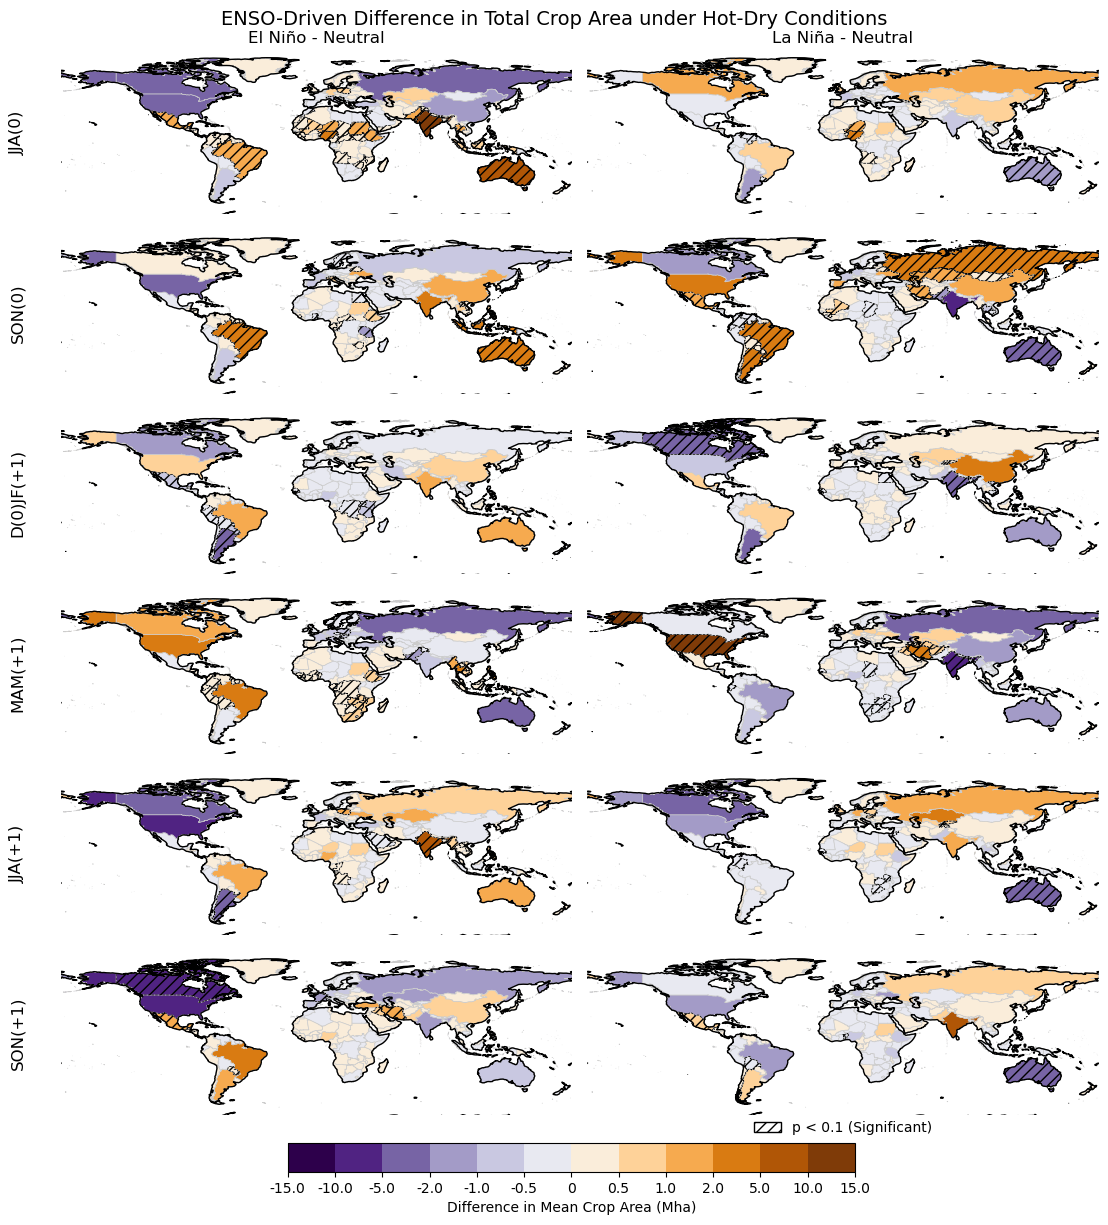

In [76]:
diff_vars = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
season_labels = {
    'jja': 'JJA(0)',
    'son': 'SON(0)',
    'djf': 'D(0)JF(+1)',
    'mam1': 'MAM(+1)',
    'jja1': 'JJA(+1)',
    'son1': 'SON(+1)'
}

# Set up figure
fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Colormap setup
# vmax = hd_spext[diff_vars].abs().max().max()
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])
# base_cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [[1, 1, 1, 1], [1, 1, 1, 1]]  # white center for no-change
# custom_cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# Set diverging colormap centered at 0
vmax = hd_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
bins = np.array([
    -15e6, -10e6, -5e6, -2e6, -1e6, -0.5e6, 0,
     0.5e6, 1e6, 2e6, 5e6, 10e6, 15e6
])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
cmap = 'PuOr_r'


# Loop to draw maps
for i, season in enumerate(seasons):
    for j, diff_col in enumerate(diff_vars):
        ax = axes[i, j]

        # Subset and merge data
        subset = hd_spext[hd_spext['Season'] == season][['Country', diff_col]]
        merged = cont1.merge(subset, on='Country', how='left')

        # Plot filled map
        merged.to_crs(epsg=4326).plot(
            column=diff_col, cmap=cmap, norm=norm,
            linewidth=0.5, edgecolor='0.8',
            legend=False, ax=ax, transform=ccrs.PlateCarree()
        )

        # Overlay hatching for significant differences
        sig_df = bootstrap_df if diff_col == 'el_minus_ne' else bootstrap_df1
        sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
        sig_regions = cont1.merge(sig_matches, left_on='Country', right_on='Country', how='inner')

        if not sig_regions.empty:
            sig_regions.to_crs(epsg=4326).plot(
                ax=ax, facecolor='none', edgecolor='black',
                linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
            )

        # Map formatting
        ax.coastlines(resolution='110m', linewidth=1)
        ax.set_aspect('auto')  # ✅ prevent aspect error
        ax.axis('off')

        # Titles and labels
        if i == 0:
            ax.set_title(diff_labels[j], fontsize=12)
        if j == 0:
            ax.annotate(season_labels[season], xy=(-0.07, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

# Shared colorbar (filter valid axes to avoid error)
valid_axes = [ax for row in axes for ax in (row if isinstance(row, (list, np.ndarray)) else [row]) if hasattr(ax, 'has_data') and ax.has_data()]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# Custom ticks and labels
tick_vals =  bins
tick_labels = [f"{x/1000000:.1f}" if x != 0 else "0" for x in tick_vals]

cbar = fig.colorbar(sm, ax=valid_axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Hatching legend
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=1, fontsize=10, frameon=False)

# Title and layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.94)
plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])
plt.show()

/tmp/ipykernel_247953/1908667579.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])


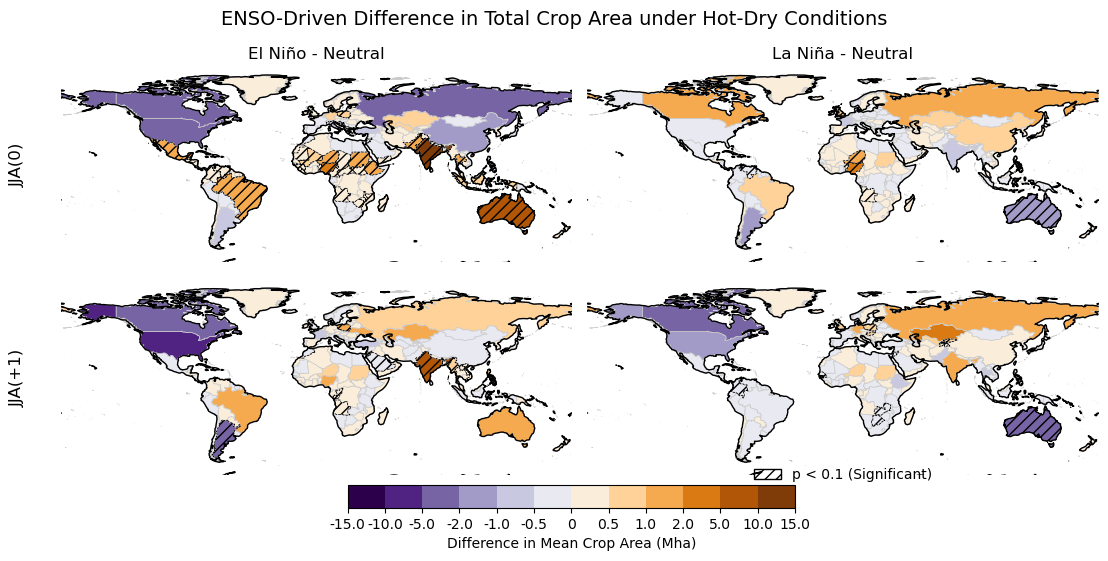

In [77]:
# Only include JJA(0) and JJA(+1)
seasons_subset = ['jja', 'jja1']
season_labels = {
    'jja': 'JJA(0)',
    'jja1': 'JJA(+1)'
}
diff_vars = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# Set up figure with 2 rows (JJA, JJA+1) and 2 columns (El Niño, La Niña)
fig, axes = plt.subplots(2, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# Color map settings
vmax = hd_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
bins = np.array([
    -15e6, -10e6, -5e6, -2e6, -1e6, -0.5e6, 0,
     0.5e6, 1e6, 2e6, 5e6, 10e6, 15e6
])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
cmap = 'PuOr_r'

# Plot loop
for i, season in enumerate(seasons_subset):
    for j, diff_col in enumerate(diff_vars):
        ax = axes[i, j]

        subset = hd_spext[hd_spext['Season'] == season][['Country', diff_col]]
        merged = cont1.merge(subset, on='Country', how='left')

        merged.to_crs(epsg=4326).plot(
            column=diff_col, cmap=cmap, norm=norm,
            linewidth=0.5, edgecolor='0.8',
            legend=False, ax=ax, transform=ccrs.PlateCarree()
        )

        sig_df = bootstrap_df if diff_col == 'el_minus_ne' else bootstrap_df1
        sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
        sig_regions = cont1.merge(sig_matches, on='Country', how='inner')

        if not sig_regions.empty:
            sig_regions.to_crs(epsg=4326).plot(
                ax=ax, facecolor='none', edgecolor='black',
                linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
            )

        ax.coastlines(resolution='110m', linewidth=1)
        ax.set_aspect('auto')
        ax.axis('off')

        if i == 0:
            ax.set_title(diff_labels[j], fontsize=12)
        if j == 0:
            ax.annotate(season_labels[season], xy=(-0.07, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# Custom ticks and labels
tick_vals =  bins
tick_labels = [f"{x/1000000:.1f}" if x != 0 else "0" for x in tick_vals]

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.046, pad=0.06, ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Legend for hatching
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.10), ncol=1, fontsize=10, frameon=False)

# Title and layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.94)
plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])
plt.show()

/tmp/ipykernel_247953/1042286538.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0.14, 0.92, 0.94])


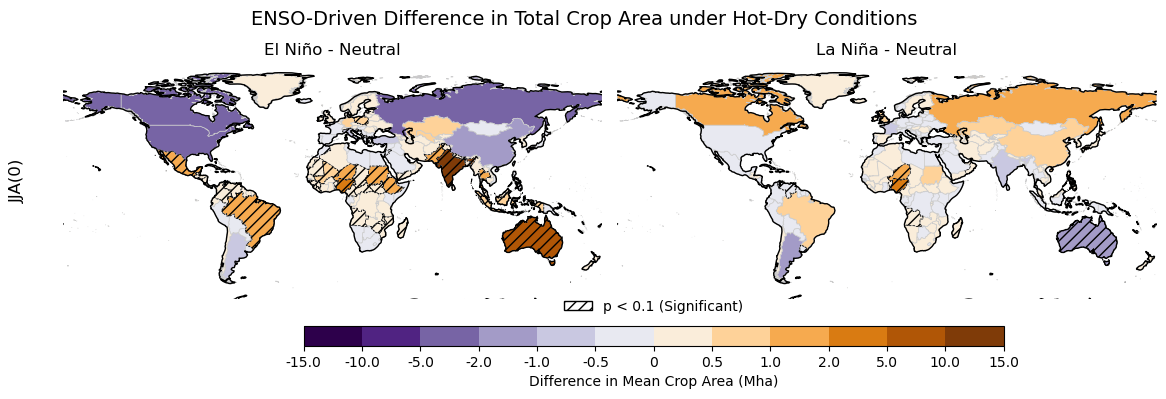

In [106]:
# --- Only include JJA(0) ---
seasons_subset = ['jja']
season_labels = {'jja': 'JJA(0)'}
diff_vars = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# Figure: 1 row (JJA only) × 2 cols (El Niño, La Niña)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.10, wspace=0.05, top=0.90)

# Colormap / bins (unchanged)
cmap = 'PuOr_r'
vmax = hd_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
bins = np.array([-15e6, -10e6, -5e6, -2e6, -1e6, -0.5e6, 0,
                  0.5e6, 1e6, 2e6, 5e6, 10e6, 15e6])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)

# Ensure axes is 2D-like for indexing
if axes.ndim == 1:
    axes = np.array([axes])

# Plot loop (only i=0 row)
for j, diff_col in enumerate(diff_vars):
    ax = axes[0, j]

    subset = hd_spext[hd_spext['Season'] == 'jja'][['Country', diff_col]]
    merged = cont1.merge(subset, on='Country', how='left')

    merged.to_crs(epsg=4326).plot(
        column=diff_col, cmap=cmap, norm=norm,
        linewidth=0.5, edgecolor='0.8',
        legend=False, ax=ax, transform=ccrs.PlateCarree()
    )

    sig_df = bootstrap_df if diff_col == 'el_minus_ne' else bootstrap_df1
    sig_matches = sig_df[(sig_df['Season'] == 'jja') & (sig_df['Significant'] == True)]
    sig_regions = cont1.merge(sig_matches, on='Country', how='inner')

    if not sig_regions.empty:
        sig_regions.to_crs(epsg=4326).plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch='///', linestyle='--',
            transform=ccrs.PlateCarree()
        )

    ax.coastlines(resolution='110m', linewidth=1)
    ax.set_aspect('auto')
    ax.axis('off')

    # Column titles
    ax.set_title(diff_labels[j], fontsize=12)

# Row label on the left
axes[0, 0].annotate(season_labels['jja'], xy=(-0.07, 0.5),
                    xycoords='axes fraction', ha='right', va='center',
                    fontsize=12, rotation=90)

# Colorbar (unchanged bins/ticks)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm._A = [] 
cax = fig.add_axes([0.30, 0.06, 0.5, 0.05])
tick_vals = bins
tick_labels = [f"{x/1e6:.1f}" if x != 0 else "0" for x in tick_vals]

cbar = fig.colorbar(sm, cax = cax, ax=axes.ravel().tolist(), orientation='horizontal',
                    fraction=0.046, pad=0.06, ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Hatching legend
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black',
                             hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center',
           bbox_to_anchor=(0.5, 1), ncol=1, fontsize=10, frameon=False)

# Title & layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Dry Conditions", fontsize=14, x=0.5, y=0.90)
plt.tight_layout(rect=[0.08, 0.14, 0.92, 0.94])
plt.show()

In [78]:
# # Set resolution
# coarse_res = 0.5
# half_res = coarse_res / 2
# crop_name = "total"
# crop_data = crop_datasets[crop_name]  # high-res crop area
# cont_crop_areas = {}

# # Loop through IPCC regions
# for idx, region in cont.iterrows():
#     region_name = region['name']
#     print(f"Processing region: {region_name}")
#     region_geom = region.geometry

#     # Initialize nested dictionary
#     cont_crop_areas_hw[region_name] = {cond: {} for cond in hot_wet_conditions.keys()}

#     # Loop through ENSO conditions
#     for condition in hot_wet_conditions.keys():
#         for season in hot_wet_conditions[condition].keys():
#             yearly_areas = []

#             for year_idx in range(len(hot_wet_conditions[condition][season])):
#                 mask = hot_wet_conditions[condition][season][year_idx]
#                 lat_vals = mask.lat.values
#                 lon_vals = mask.lon.values
#                 total_crop_area = 0

#                 for i, lat in enumerate(lat_vals):
#                     for j, lon in enumerate(lon_vals):
#                         if mask.values[i, j]:
#                             # Define bounds for the coarse grid cell
#                             cell_geom = box(lon - half_res, lat - half_res, lon + half_res, lat + half_res)

#                             # Check intersection with IPCC region
#                             if region_geom.intersects(cell_geom):
#                                 # Clip high-res crop area
#                                 lat_min, lat_max = lat - half_res, lat + half_res
#                                 lon_min, lon_max = lon - half_res, lon + half_res
#                                 fine_area = crop_data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
#                                 total_crop_area += np.nansum(fine_area)

#                 yearly_areas.append(total_crop_area)

#             # Save mean crop area across years
#             cont_crop_areas_hw[region_name][condition][season] = np.mean(yearly_areas)

# # ✅ Print final results
# print(f"Mean crop area under hot-wet conditions by Country:")
# for region, conds in cont_crop_areas_hw.items():
#     for condition, seasons in conds.items():
#         for season, area in seasons.items():
#             print(f"{region} | {condition} | {season}: {area:.2f} ha")

In [79]:
# records = []
# for region, conds in cont_crop_areas_hw.items():
#     for condition, seasons in conds.items():
#         for season, area in seasons.items():
#             records.append({
#                 'Country': region,
#                 'Condition': condition,
#                 'Season': season,
#                 'Area_ha': area
#             })

# df = pd.DataFrame(records)
# df.to_csv("/home/madhulika.gurazada/paper2/Data/Spatial_extent/HW_Country.csv", index=False)  # `index=False` avoids saving row numbers

In [80]:
hw = pd.read_csv("/home/madhulika.gurazada/paper2/Data/Spatial_extent/HW_Country.csv")  
hw

,Country,Condition,Season,Area_ha
0,Northern Mariana Islands,el,jja,0.000000
1,Northern Mariana Islands,el,son,0.000000
2,Northern Mariana Islands,el,djf,0.000000
3,Northern Mariana Islands,el,mam1,0.000000
4,Northern Mariana Islands,el,jja1,0.000000
...,...,...,...,...
4603,Gibraltar,ne,son,0.000000
4604,Gibraltar,ne,djf,1173.074295
4605,Gibraltar,ne,mam1,0.000000
4606,Gibraltar,ne,jja1,0.000000


In [81]:
# Pivot the dataframe to get 'el', 'ne', 'la' as separate columns
hw_spext = hw.pivot_table(index=['Country', 'Season'],
                          columns='Condition',
                          values='Area_ha').reset_index()

# Rename columns for clarity
hw_spext.columns.name = None  # remove the column name (Condition)
hw_spext = hw_spext.rename(columns={
    'el': 'area_el',
    'ne': 'area_ne',
    'la': 'area_la'
})

# Calculate differences
hw_spext['el_minus_ne'] = hw_spext['area_el'] - hw_spext['area_ne']
hw_spext['la_minus_ne'] = hw_spext['area_la'] - hw_spext['area_ne']

season_order = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# Convert to categorical and sort
hw_spext['Season'] = pd.Categorical(hw_spext['Season'], categories=season_order, ordered=True)
hw_spext = hw_spext.sort_values('Season').reset_index(drop=True)
hw_spext

,Country,Season,area_el,area_la,area_ne,el_minus_ne,la_minus_ne
0,Suriname,jja,17910.714700,19343.570248,5849.578819,12061.135881,13493.991429
1,Montenegro,jja,1333.040377,0.000000,0.000000,1333.040377,0.000000
2,Cyprus,jja,11535.154527,7697.109992,0.000000,11535.154527,7697.109992
3,Montserrat,jja,0.000000,0.000000,0.000000,0.000000,0.000000
4,Uruguay,jja,470321.054400,7055.352488,179347.585210,290973.469190,-172292.232722
...,...,...,...,...,...,...,...
1531,Madagascar,son1,106143.671207,43100.637966,53020.049795,53123.621412,-9919.411829
1532,Macao,son1,0.000000,0.000000,686.620254,-686.620254,-686.620254
1533,Ma'tan al-Sarra,son1,0.000000,0.000000,0.000000,0.000000,0.000000
1534,Mauritania,son1,260.235624,161.201766,952.710420,-692.474795,-791.508654


In [82]:
# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Set diverging colormap centered at 0
# vmax = hw_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
# # bins = np.linspace(-vmax, vmax, 9)  # 8 intervals
# # norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
# # cmap = 'PuOr_r'

# # Define discrete bins (e.g., 8 bins, with two central bins around 0)
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])

# # Get the base colormap and convert to list
# base_cmap = plt.get_cmap('PuOr', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))

# # Replace center two colors with white
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [ [1,1,1,1], [1,1,1,1] ]  

# # Create new ListedColormap
# custom_cmap = mcolors.ListedColormap(colors)

# # Create BoundaryNorm
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Filter the reshaped difference data for the season
#         subset = hw_spext[hw_spext['Season'] == season][['Country', diff_col]]

#         # Merge with shapefile
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Plot difference
#         merged.to_crs(epsg=4326).plot(column=diff_col, cmap=custom_cmap, norm=norm, 
#                                       linewidth=0.5, edgecolor='0.8', 
#                                       legend=False, ax=ax, transform=ccrs.PlateCarree())
#         # Add coastlines
#         ax.coastlines(resolution='110m', linewidth=1)

#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.set_ylabel(season.upper(), fontsize=11)
            
#         # Row labels using annotate (optional: better positioning than set_ylabel)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

#         ax.axis('off')

# # Add shared colorbar
# sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (km²)")

# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96]) 
# plt.show()

In [83]:
# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Set diverging colormap centered at 0
# vmax = hw_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
# bins = np.linspace(-vmax, vmax, 9)  # 8 intervals
# norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
# cmap = 'PuOr'

# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Filter the reshaped difference data for the season
#         subset = hw_spext[hw_spext['Season'] == season][['Country', diff_col]]

#         # Merge with shapefile
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Plot difference
#         merged.to_crs(epsg=4326).plot(column=diff_col, cmap=cmap, norm=norm, 
#                                       linewidth=0.5, edgecolor='0.8', 
#                                       legend=False, ax=ax, transform=ccrs.PlateCarree())
#         # Add coastlines
#         ax.coastlines(resolution='110m', linewidth=1)

#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.set_ylabel(season.upper(), fontsize=11)
            
#         # Row labels using annotate (optional: better positioning than set_ylabel)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

#         ax.axis('off')

# # Add shared colorbar
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (km²)")

# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96]) 
# plt.show()

In [84]:
# diff_vars = ['el_minus_ne', 'la_minus_ne']
# diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# # Set up figure
# fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Colormap setup
# vmax = hw_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])
# base_cmap = plt.get_cmap('PuOr', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [[1, 1, 1, 1], [1, 1, 1, 1]]
# custom_cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# for i, season in enumerate(seasons):
#     for j, diff_col in enumerate(diff_vars):
#         ax = axes[i, j]

#         # Filter and merge
#         subset = hw_spext[hw_spext['Season'] == season][['Country', diff_col]]
#         merged = cont1.merge(subset, on='Country', how='left')

#         # Base fill plot
#         merged.to_crs(epsg=4326).plot(
#             column=diff_col, cmap=custom_cmap, norm=norm,
#             linewidth=0.5, edgecolor='0.8',
#             legend=False, ax=ax, transform=ccrs.PlateCarree()
#         )

#         # Get corresponding bootstrap significance table
#         sig_df = bootstrap_df2 if diff_col == 'el_minus_ne' else bootstrap_df3
#         sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
#         sig_regions = cont1.merge(sig_matches, left_on='Country', right_on='Country', how='inner')

#         if not sig_regions.empty:
#             sig_regions.to_crs(epsg=4326).plot(
#                 ax=ax, facecolor='none', edgecolor='black',
#                 linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
#             )
            
#         # Map formatting
#         ax.coastlines(resolution='110m', linewidth=1)
#         ax.set_aspect('auto')  # ✅ prevent aspect error
#         ax.axis('off')

#         # Titles and labels
#         if i == 0:
#             ax.set_title(diff_labels[j], fontsize=12)
#         if j == 0:
#             ax.annotate(season.upper(), xy=(-0.07, 0.5), xycoords='axes fraction',
#                         ha='right', va='center', fontsize=12, rotation=90)

# # Shared colorbar (filter valid axes to avoid error)
# valid_axes = [ax for row in axes for ax in (row if isinstance(row, (list, np.ndarray)) else [row]) if hasattr(ax, 'has_data') and ax.has_data()]
# sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
# sm._A = []
# cbar = fig.colorbar(sm, ax=valid_axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=bins)
# cbar.set_label("Difference in Mean Crop Area (km²)")

# # Hatching legend
# hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
# plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=10, frameon=False)

# # Title and layout
# plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.94)
# plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96]) 
# plt.show()

/tmp/ipykernel_247953/1423427147.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])


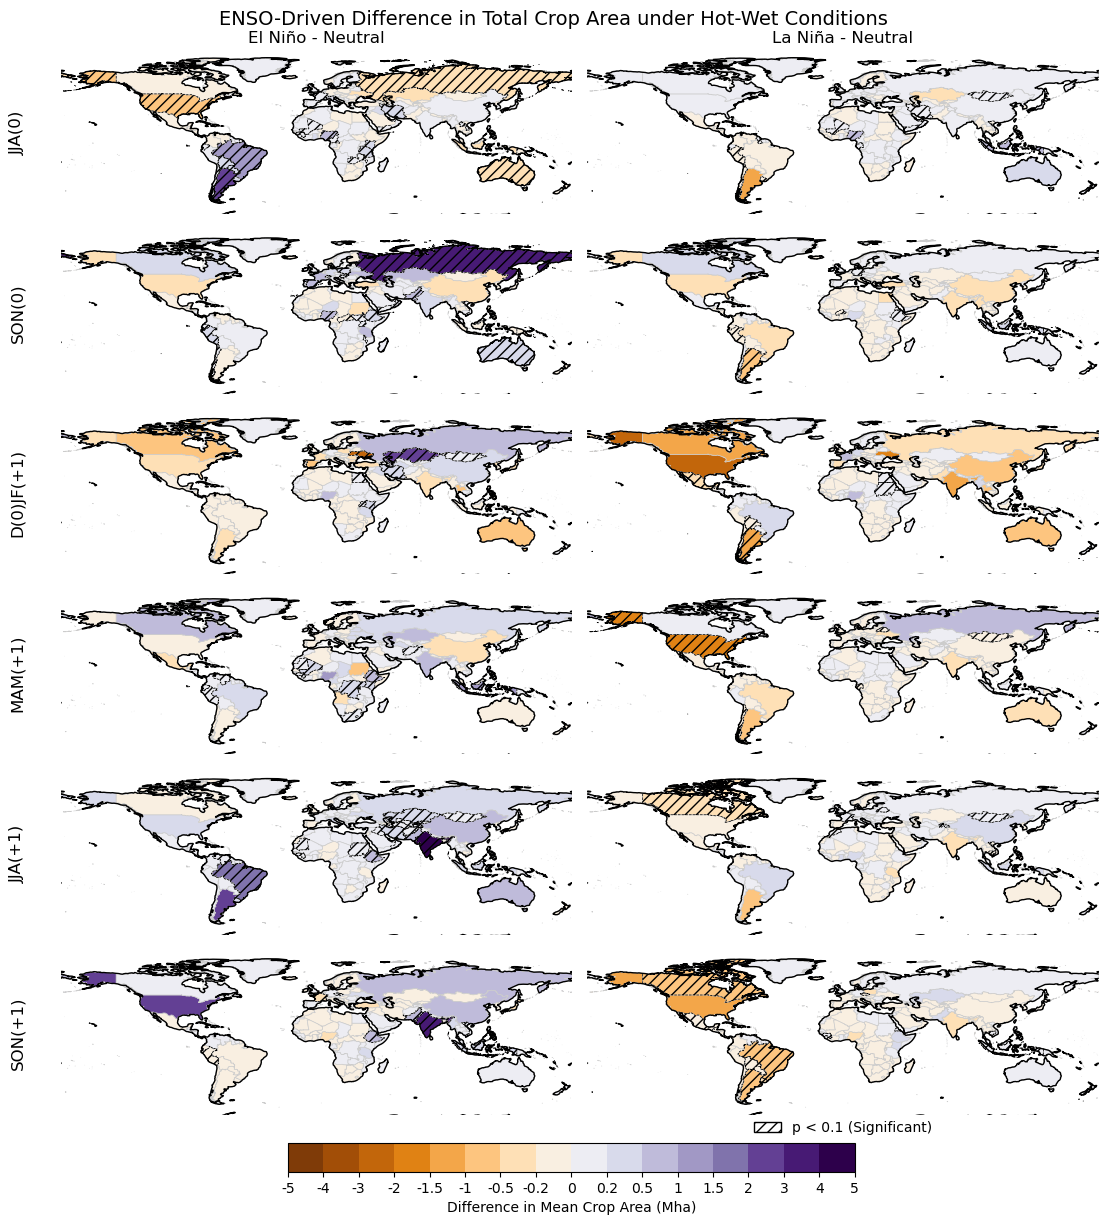

In [85]:
diff_vars = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
season_labels = {
    'jja': 'JJA(0)',
    'son': 'SON(0)',
    'djf': 'D(0)JF(+1)',
    'mam1': 'MAM(+1)',
    'jja1': 'JJA(+1)',
    'son1': 'SON(+1)'
}

# Set up figure
fig, axes = plt.subplots(len(seasons), len(diff_vars), figsize=(14, 14), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# # Colormap setup
# vmax = hd_spext[diff_vars].abs().max().max()
# bins = np.array([-vmax, -0.75*vmax, -0.5*vmax, -0.25*vmax, 0, 0.25*vmax, 0.5*vmax, 0.75*vmax, vmax])
# base_cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
# colors = base_cmap(np.arange(len(bins) - 1))
# middle = len(colors) // 2
# colors[middle - 1: middle + 1] = [[1, 1, 1, 1], [1, 1, 1, 1]]  # white center for no-change
# custom_cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bins, len(bins) - 1)

# Set diverging colormap centered at 0
vmax = hw_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
bins = np.array([
    -5e6, -4e6, -3e6, -2e6, -1.5e6, -1e6, -0.5e6, -0.2e6, 0,
     0.2e6, 0.5e6, 1e6, 1.5e6, 2e6, 3e6, 4e6, 5e6
])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
cmap = 'PuOr'

# Loop to draw maps
for i, season in enumerate(seasons):
    for j, diff_col in enumerate(diff_vars):
        ax = axes[i, j]

        # Subset and merge data
        subset = hw_spext[hw_spext['Season'] == season][['Country', diff_col]]
        merged = cont1.merge(subset, on='Country', how='left')

        # Plot filled map
        merged.to_crs(epsg=4326).plot(
            column=diff_col, cmap=cmap, norm=norm,
            linewidth=0.5, edgecolor='0.8',
            legend=False, ax=ax, transform=ccrs.PlateCarree()
        )

        # Overlay hatching for significant differences
        sig_df = bootstrap_df2 if diff_col == 'el_minus_ne' else bootstrap_df3
        sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
        sig_regions = cont1.merge(sig_matches, left_on='Country', right_on='Country', how='inner')

        if not sig_regions.empty:
            sig_regions.to_crs(epsg=4326).plot(
                ax=ax, facecolor='none', edgecolor='black',
                linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
            )

        # Map formatting
        ax.coastlines(resolution='110m', linewidth=1)
        ax.set_aspect('auto')  # ✅ prevent aspect error
        ax.axis('off')

        # Titles and labels
        if i == 0:
            ax.set_title(diff_labels[j], fontsize=12)
        if j == 0:
            ax.annotate(season_labels[season], xy=(-0.07, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

# Shared colorbar (filter valid axes to avoid error)
valid_axes = [ax for row in axes for ax in (row if isinstance(row, (list, np.ndarray)) else [row]) if hasattr(ax, 'has_data') and ax.has_data()]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

def format_tick(x):
    val = x / 1e6  # convert to millions

    if x == 0:
        return "0"
    elif abs(val) < 1:      # show one decimal for small values
        return f"{val:.1f}"
    elif val % 1 == 0:      # whole numbers, no decimal
        return f"{int(val)}"
    else:                   # 1.5, 2.5, etc.
        return f"{val:.1f}"
    
# Custom ticks and labels
tick_vals =  bins
# tick_labels = [f"{x/1000000:.1f}" if x != 0 else "0" for x in tick_vals]
tick_labels = [format_tick(x) for x in tick_vals]

cbar = fig.colorbar(sm, ax=valid_axes, orientation='horizontal', fraction=0.025, pad=0.08, ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Hatching legend
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=1, fontsize=10, frameon=False)

# Title and layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.94)
plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])
plt.show()

/tmp/ipykernel_247953/704858317.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])


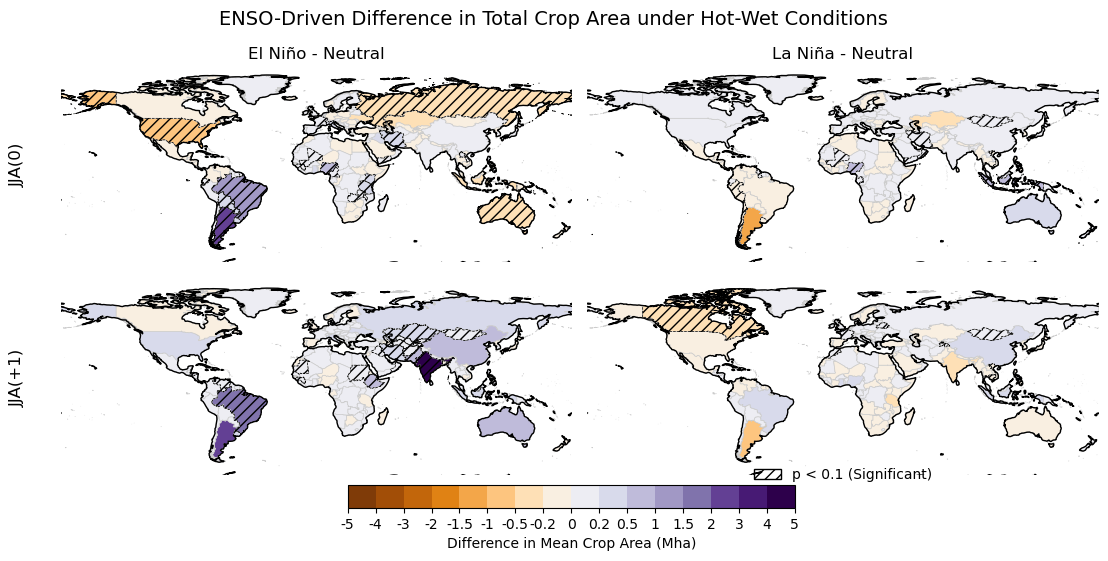

In [107]:
# Only include JJA(0) and JJA(+1)
seasons_subset = ['jja', 'jja1']
season_labels = {
    'jja': 'JJA(0)',
    'jja1': 'JJA(+1)'
}
diff_vars = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# Set up figure with 2 rows (JJA, JJA+1) and 2 columns (El Niño, La Niña)
fig, axes = plt.subplots(2, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.15, wspace=0.05, top=0.92)

# Color map settings
vmax = hw_spext[['el_minus_ne', 'la_minus_ne']].abs().max().max()
bins = np.array([
    -5e6, -4e6, -3e6, -2e6, -1.5e6, -1e6, -0.5e6, -0.2e6, 0,
     0.2e6, 0.5e6, 1e6, 1.5e6, 2e6, 3e6, 4e6, 5e6
])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)
cmap = 'PuOr'

# Plot loop
for i, season in enumerate(seasons_subset):
    for j, diff_col in enumerate(diff_vars):
        ax = axes[i, j]

        subset = hw_spext[hw_spext['Season'] == season][['Country', diff_col]]
        merged = cont1.merge(subset, on='Country', how='left')

        merged.to_crs(epsg=4326).plot(
            column=diff_col, cmap=cmap, norm=norm,
            linewidth=0.5, edgecolor='0.8',
            legend=False, ax=ax, transform=ccrs.PlateCarree()
        )

        sig_df = bootstrap_df2 if diff_col == 'el_minus_ne' else bootstrap_df3
        sig_matches = sig_df[(sig_df['Season'] == season) & (sig_df['Significant'] == True)]
        sig_regions = cont1.merge(sig_matches, on='Country', how='inner')

        if not sig_regions.empty:
            sig_regions.to_crs(epsg=4326).plot(
                ax=ax, facecolor='none', edgecolor='black',
                linewidth=0.5, hatch='///', linestyle='--', transform=ccrs.PlateCarree()
            )

        ax.coastlines(resolution='110m', linewidth=1)
        ax.set_aspect('auto')
        ax.axis('off')

        if i == 0:
            ax.set_title(diff_labels[j], fontsize=12)
        if j == 0:
            ax.annotate(season_labels[season], xy=(-0.07, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

def format_tick(x):
    val = x / 1e6  # convert to millions

    if x == 0:
        return "0"
    elif abs(val) < 1:      # show one decimal for small values
        return f"{val:.1f}"
    elif val % 1 == 0:      # whole numbers, no decimal
        return f"{int(val)}"
    else:                   # 1.5, 2.5, etc.
        return f"{val:.1f}"
    
# Custom ticks and labels
tick_vals =  bins
# tick_labels = [f"{x/1000000:.1f}" if x != 0 else "0" for x in tick_vals]
tick_labels = [format_tick(x) for x in tick_vals]

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.046, pad=0.06, ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Legend for hatching
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center', bbox_to_anchor=(0.5, -0.10), ncol=1, fontsize=10, frameon=False)

# Title and layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.94)
plt.tight_layout(rect=[0.1, 0.14, 0.9, 0.96])
plt.show()

/tmp/ipykernel_247953/897047341.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0.14, 0.92, 0.94])


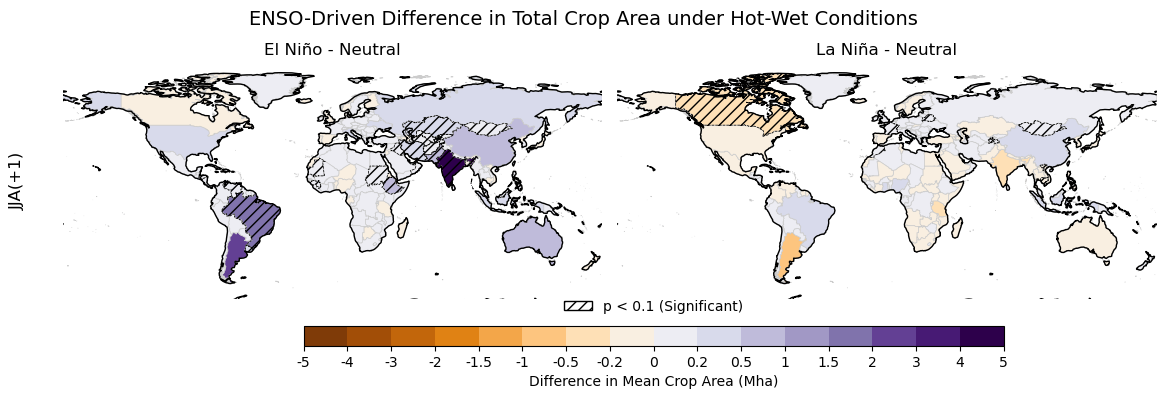

In [108]:
# --- Only include JJA(+1) ---
seasons_subset = ['jja1']
season_labels = {'jja1': 'JJA(+1)'}
diff_vars   = ['el_minus_ne', 'la_minus_ne']
diff_labels = ['El Niño - Neutral', 'La Niña - Neutral']

# Figure: 1 row (JJA+1 only) × 2 cols (El Niño, La Niña)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.10, wspace=0.05, top=0.90)

# Colormap / bins (same style)
cmap = 'PuOr'
bins = np.array([-5e6, -4e6, -3e6, -2e6, -1.5e6, -1e6, -0.5e6, -0.2e6, 0,
                  0.2e6, 0.5e6, 1e6, 1.5e6, 2e6, 3e6, 4e6, 5e6])
norm = mcolors.BoundaryNorm(bins, ncolors=plt.get_cmap(cmap).N)

# Ensure axes is 2D-like for indexing consistency
if axes.ndim == 1:
    axes = np.array([axes])

# Plot loop (only JJA+1 row)
for j, diff_col in enumerate(diff_vars):
    ax = axes[0, j]

    subset = hw_spext[hw_spext['Season'] == 'jja1'][['Country', diff_col]]
    merged = cont1.merge(subset, on='Country', how='left')

    merged.to_crs(epsg=4326).plot(
        column=diff_col, cmap=cmap, norm=norm,
        linewidth=0.5, edgecolor='0.8',
        legend=False, ax=ax, transform=ccrs.PlateCarree()
    )

    # Significance hatching (p < 0.1)
    sig_df = bootstrap_df2 if diff_col == 'el_minus_ne' else bootstrap_df3
    sig_matches = sig_df[(sig_df['Season'] == 'jja1') & (sig_df['Significant'] == True)]
    sig_regions = cont1.merge(sig_matches, on='Country', how='inner')

    if not sig_regions.empty:
        sig_regions.to_crs(epsg=4326).plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch='///', linestyle='--',
            transform=ccrs.PlateCarree()
        )

    ax.coastlines(resolution='110m', linewidth=1)
    ax.set_aspect('auto')
    ax.axis('off')

    # Column titles
    ax.set_title(diff_labels[j], fontsize=12)

# Row label on the left
axes[0, 0].annotate(season_labels['jja1'], xy=(-0.07, 0.5),
                    xycoords='axes fraction', ha='right', va='center',
                    fontsize=12, rotation=90)

# --- Long & thick custom colorbar (same formatting as saved code) ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm._A = []
cax = fig.add_axes([0.30, 0.06, 0.5, 0.05])  # [left, bottom, width, height]

def format_tick(x):
    val = x / 1e6
    if x == 0:
        return "0"
    elif abs(val) < 1:
        return f"{val:.1f}"
    elif val % 1 == 0:
        return f"{int(val)}"
    else:
        return f"{val:.1f}"

tick_vals   = bins
tick_labels = [format_tick(x) for x in tick_vals]

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=tick_vals)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Difference in Mean Crop Area (Mha)")

# Hatching legend (same placement style)
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='black',
                             hatch='///', label='p < 0.1 (Significant)')
plt.legend(handles=[hatch_patch], loc='lower center',
           bbox_to_anchor=(0.5, 1), ncol=1, fontsize=10, frameon=False)

# Title & layout
plt.suptitle("ENSO-Driven Difference in Total Crop Area under Hot-Wet Conditions", fontsize=14, x=0.5, y=0.90)
plt.tight_layout(rect=[0.08, 0.14, 0.92, 0.94])
plt.show()
